In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import os
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.inspection import permutation_importance

import json


In [3]:
BASE_PATH= Path(os.getcwd()).parent

DATASET_PATH= BASE_PATH / 'dataset'
DATA_PATH= DATASET_PATH / 'raw' / 'UCI_Credit_Card.csv'

TRAIN_RAW_PATH= DATASET_PATH / 'split' / 'raw' / 'train_set.csv'
TEST_RAW_PATH= DATASET_PATH / 'split' / 'raw' / 'test_set.csv'
TRAIN_PREPRO_PATH= DATASET_PATH / 'split' /  'preprocessed' /'train_set.csv'
TEST_PREPRO_PATH= DATASET_PATH / 'split' /  'preprocessed' /'test_set.csv'

ARTIFACTS_PATH= BASE_PATH / 'artifacts'
FEATURES_PATH= ARTIFACTS_PATH / 'final_features.json'


In [4]:
full_df=pd.read_csv(DATA_PATH)
df=full_df.copy()

In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


First i need to understand what i am looking at:
>ID: ID of each client

>LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit

>SEX: Gender (1=male, 2=female)

>EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

>MARRIAGE: Marital status (1=married, 2=single, 3=others)

>AGE: Age in years

>PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

>PAY_2: Repayment status in August, 2005 (scale same as above)

>PAY_3: Repayment status in July, 2005 (scale same as above)

>PAY_4: Repayment status in June, 2005 (scale same as above)

>PAY_5: Repayment status in May, 2005 (scale same as above)

>PAY_6: Repayment status in April, 2005 (scale same as above)

>BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

>BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

>BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

>BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

>BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

>BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

>PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

>PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

>PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

>PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

>PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

>PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

>default.payment.next.month: Default payment (1=yes, 0=no) ```target```


in the description tha value -2 was not mentioned, so i made my own research and found that -2 is for ```no consumption```

what i can see is that:
1) We need to work with the columns such : PAY_N, BILL_AMTN, PAY_AMTN as an object types since i think as an int it will not really informative
2) About the education i am thinking about combining 5 and 6, maybe even 4 and call them as others.
3) I need to see the LIMIT_BAL distribution to see what i can do here

In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

there is no null values which is good

In [8]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [9]:
df.drop(columns=['ID'], inplace=True)

In [10]:
#splitting the dataset to train and test set
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['default.payment.next.month'])

In [13]:
os.makedirs(TRAIN_RAW_PATH.parent, exist_ok=True)
os.makedirs(TEST_RAW_PATH.parent, exist_ok=True)
with open(TRAIN_RAW_PATH, "w", encoding="utf-8") as f:
    train_df.to_csv(f, index=False)
with open(TEST_RAW_PATH, "w", encoding="utf-8") as f:
    test_df.to_csv(f, index=False)

In [14]:
#change the column dtypes
cat_cols=['SEX', 'EDUCATION', 'MARRIAGE',
          'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
num_cols=list(set(df.columns)-set(cat_cols))
df[cat_cols]=df[cat_cols].astype('object')

The PAY_n need ordinal encoder after we start making the pipeline because the number has an order

In [15]:
def num_plotting_distribution(data, column, figsize=(10,5)):
    plt.figure(figsize=figsize)
    sns.histplot(data[column], kde=True, color='skyblue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()

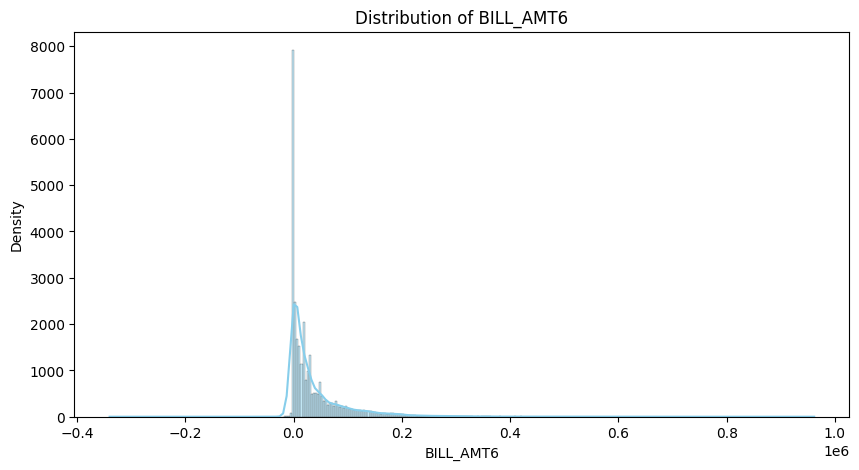

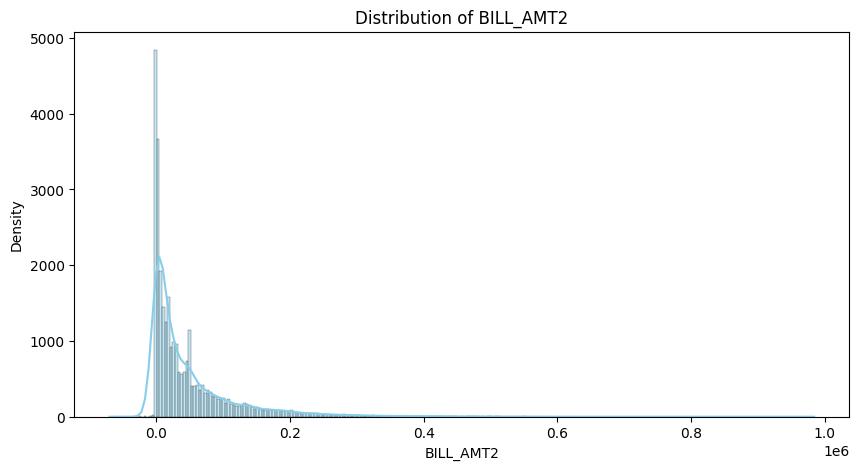

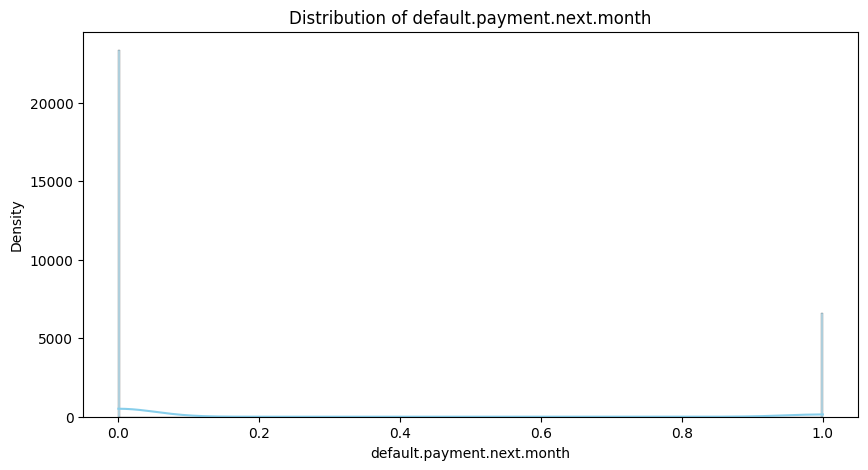

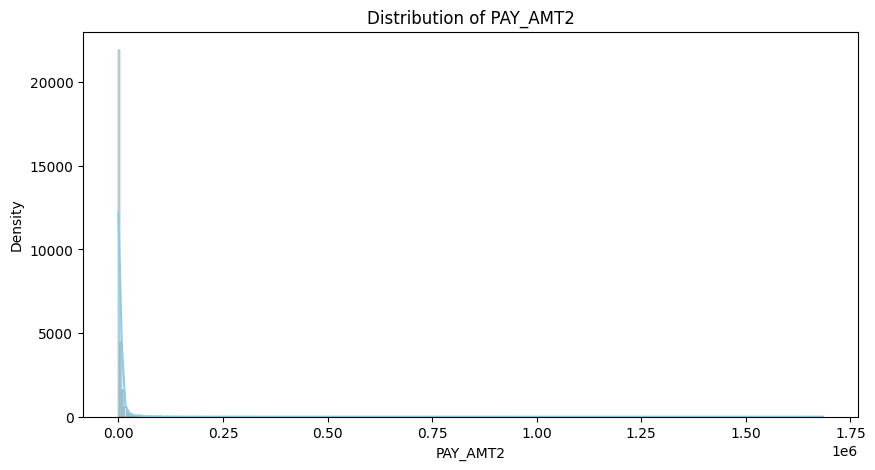

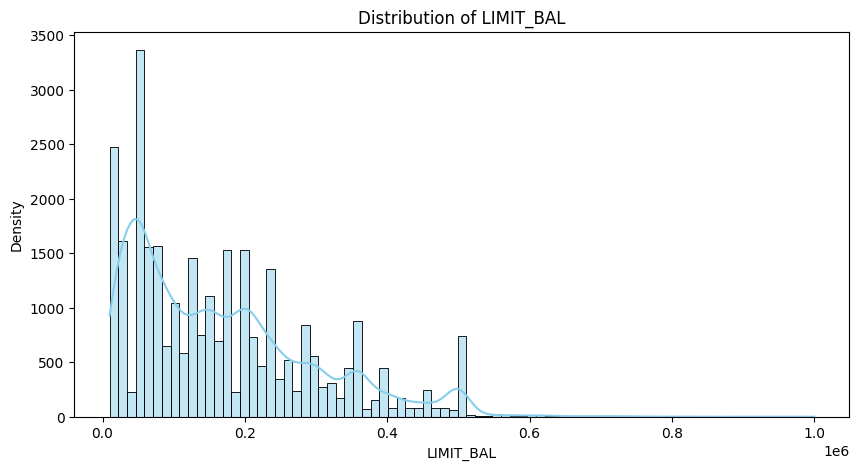

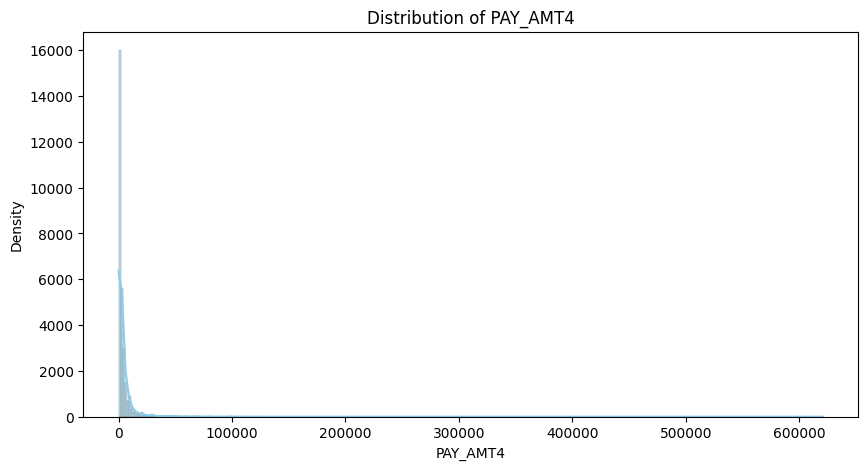

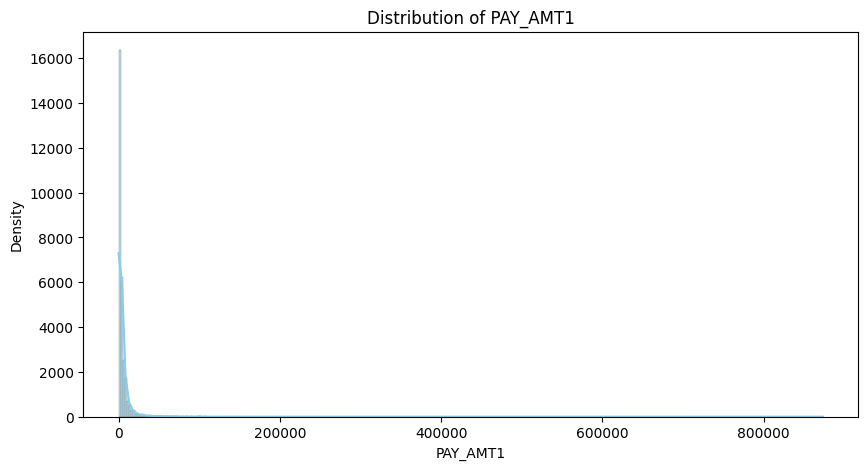

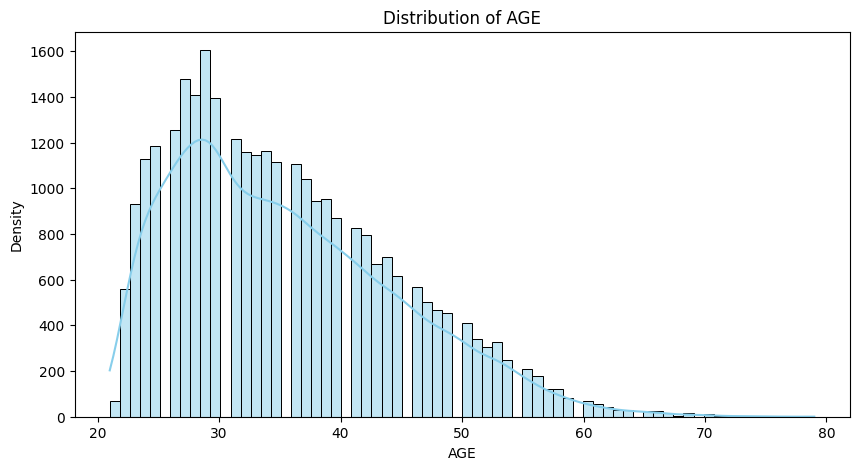

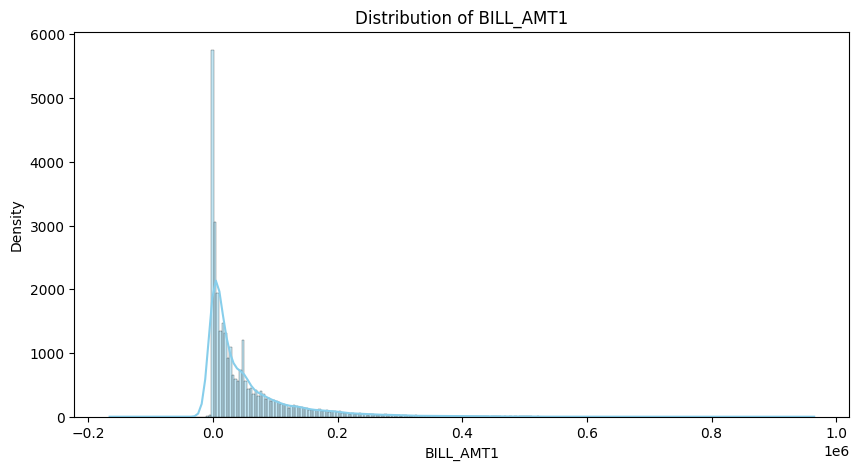

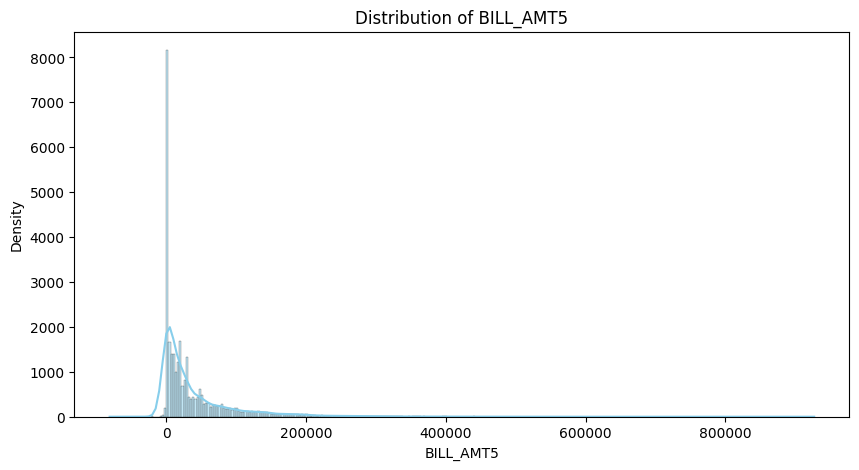

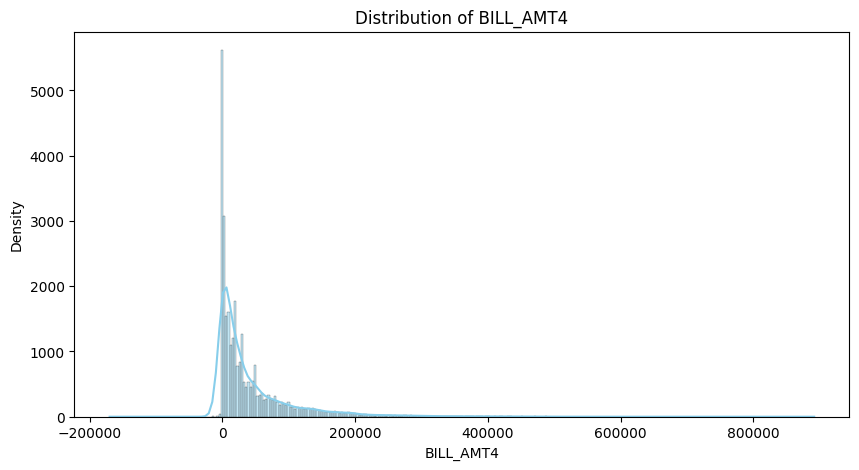

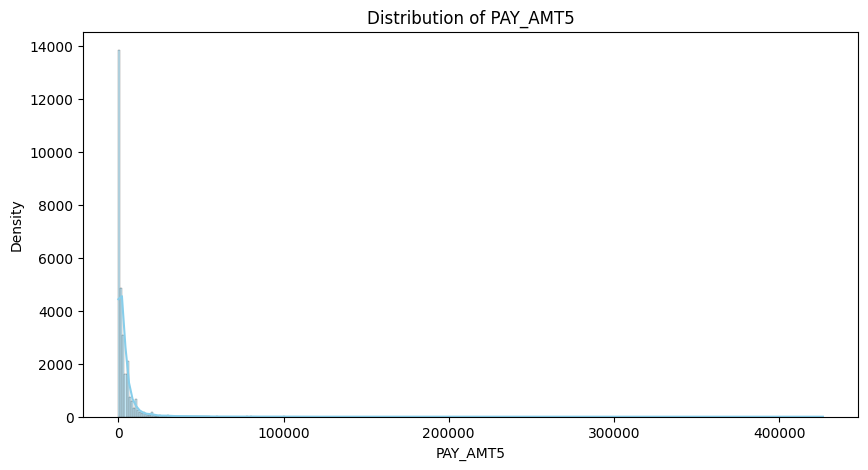

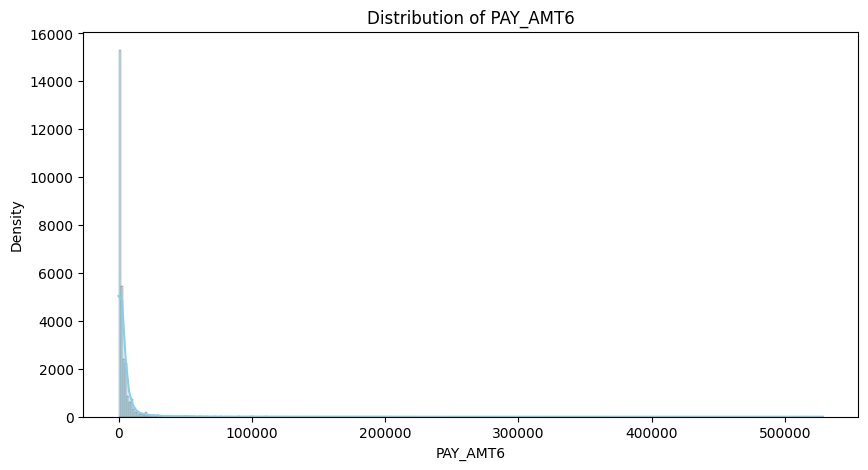

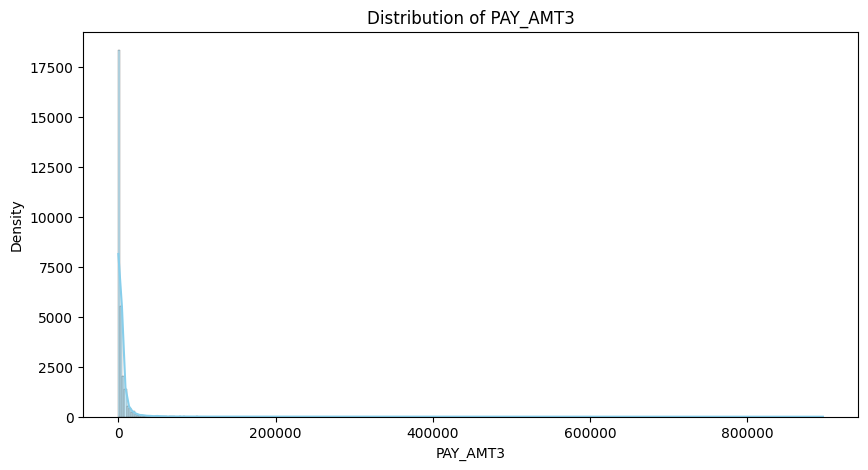

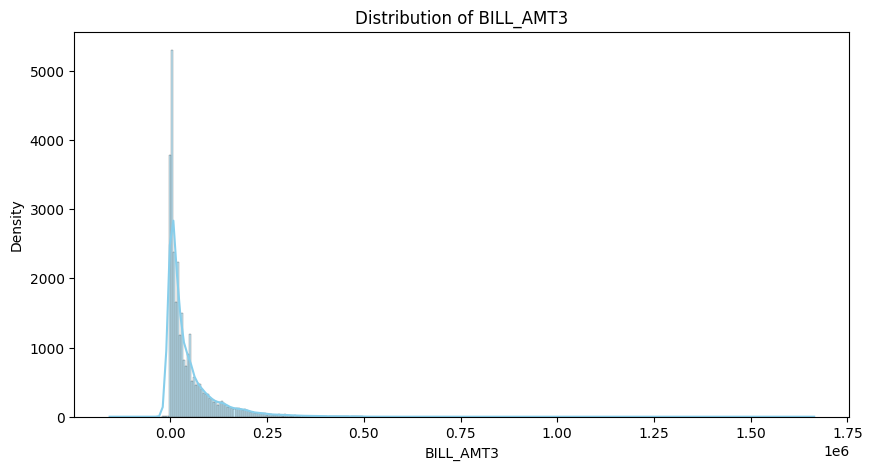

In [16]:
for col in num_cols:
    num_plotting_distribution(df, col)

From these graph we can see that (DAY_AMTN, BILL_AMTN)->long tails-> maybe the np.1log will be used. Moreover i may have group these values into groups but since i do not have clear idea what value can be considered as a lot or not, it will be quite objective, that is why i am gonna leave it as the numerical features 

What i found after further analysis:
One important thing is the feat PAY_AMTN values start from 0, but BILL_AMTN has the negative values that is why we can use for it the no.log1p

In [17]:
def cat_plotting_distribution(data, column, figsize=(10,5)):
    plt.figure(figsize=figsize)
    sns.countplot(x=data[column], palette='pastel')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()
    print(df[col].value_counts())

In [18]:
#some slight modification to the categorical 
# columns for better visualization
df['EDUCATION']=df['EDUCATION'].replace({1:'graduate school', 2:'university', 3:'high school', 4:'others', 5:'others', 6:'unknown', 0:'unknown'})
#EDUCATION will be later replaced again(4,5,6,0 will be combined into one class "others")
df['SEX']=df['SEX'].replace({1:'male', 2:'female'})
df["MARRIAGE"]=df["MARRIAGE"].replace({1:'married', 2:'single', 3:'others', 0:'others'})

In [19]:
#the same stuff for test_df
test_df['EDUCATION']=test_df['EDUCATION'].replace({1:'graduate school', 2:'university', 3:'high school', 4:'others', 5:'others', 6:'unknown', 0:'unknown'})
test_df['SEX']=test_df['SEX'].replace({1:'male', 2:'female'})
test_df["MARRIAGE"]=test_df["MARRIAGE"].replace({1:'married', 2:'single', 3:'others', 0:'others'})


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


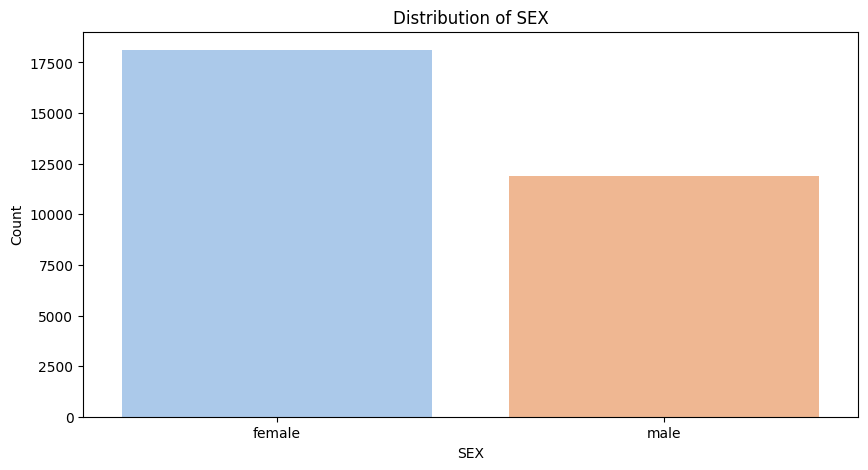

SEX
female    18112
male      11888
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


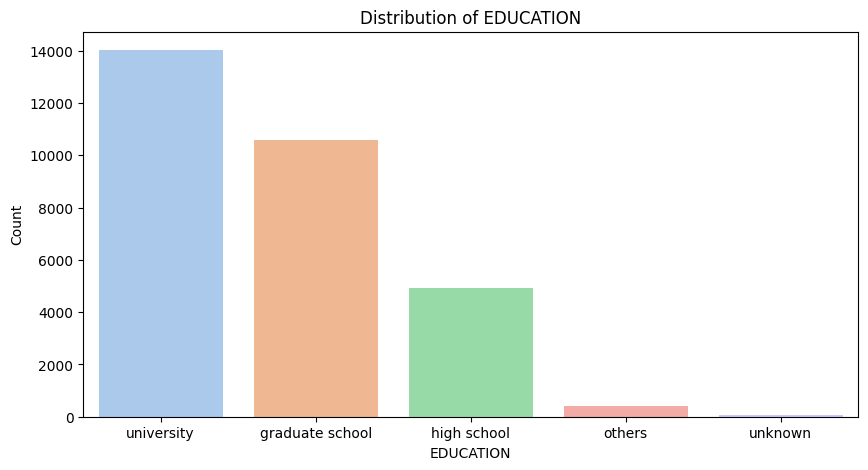

C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


EDUCATION
university         14030
graduate school    10585
high school         4917
others               403
unknown               65
Name: count, dtype: int64


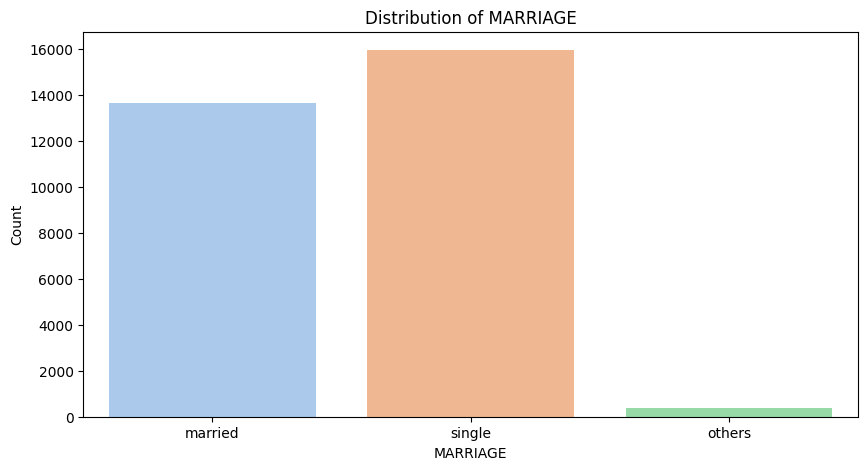

MARRIAGE
single     15964
married    13659
others       377
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


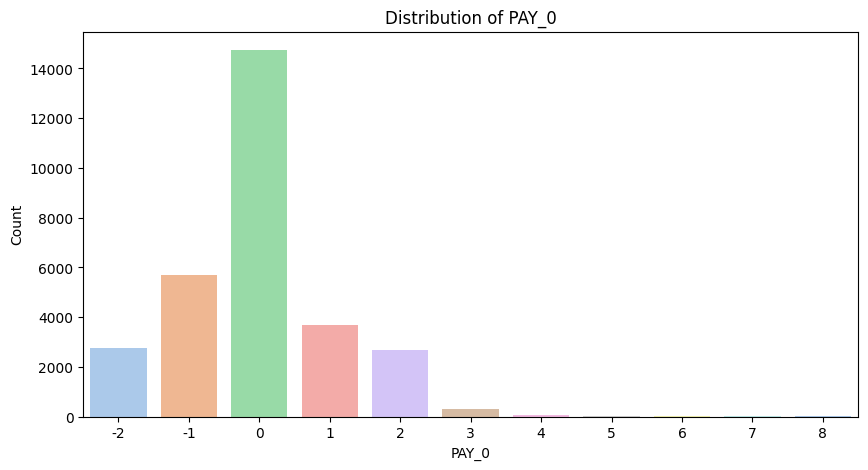

PAY_0
0     14737
-1     5686
1      3688
-2     2759
2      2667
3       322
4        76
5        26
8        19
6        11
7         9
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


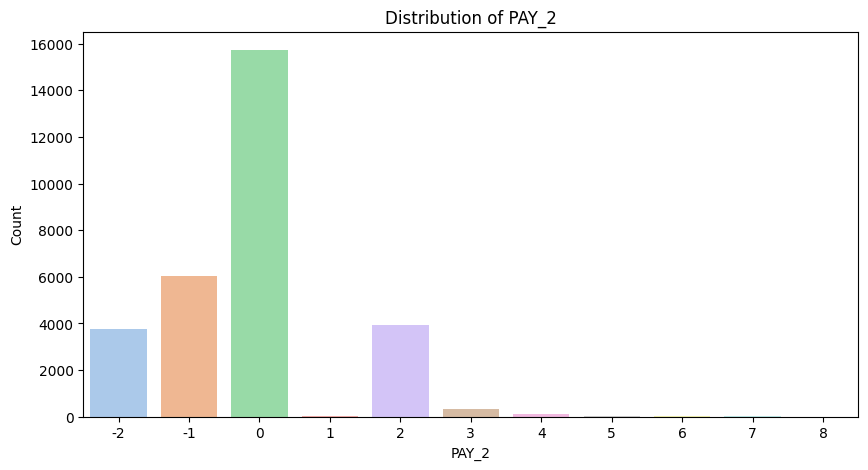

PAY_2
0     15730
-1     6050
2      3927
-2     3782
3       326
4        99
1        28
5        25
7        20
6        12
8         1
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


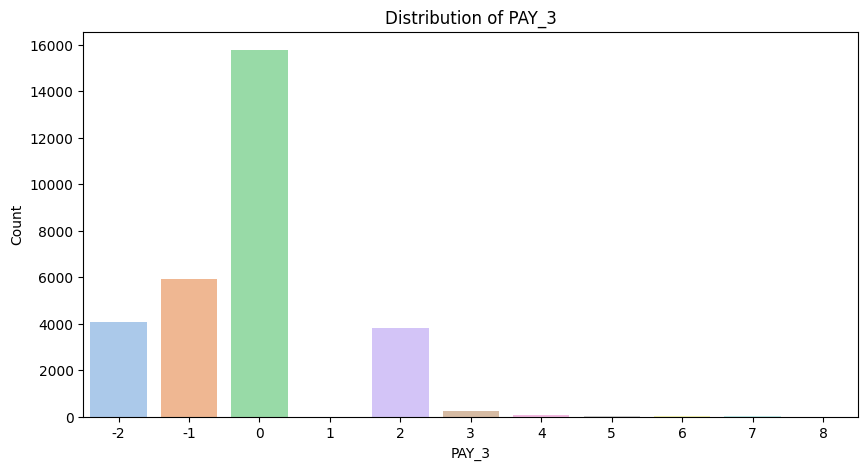

PAY_3
0     15764
-1     5938
-2     4085
2      3819
3       240
4        76
7        27
6        23
5        21
1         4
8         3
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


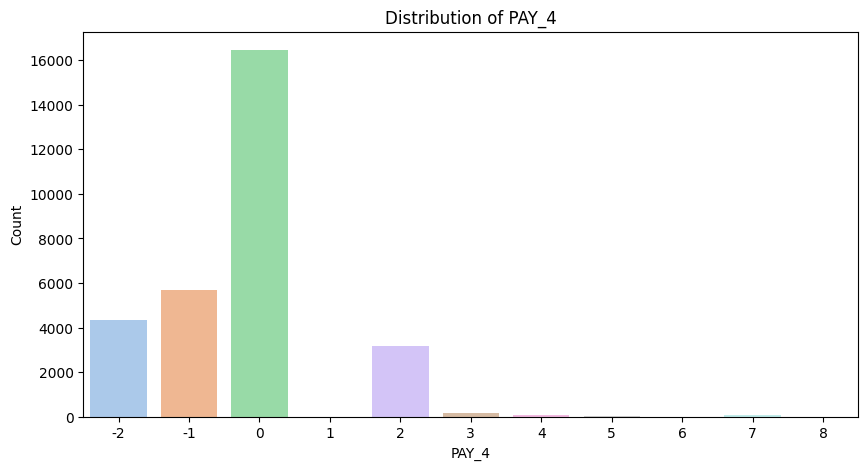

PAY_4
0     16455
-1     5687
-2     4348
2      3159
3       180
4        69
7        58
5        35
6         5
1         2
8         2
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


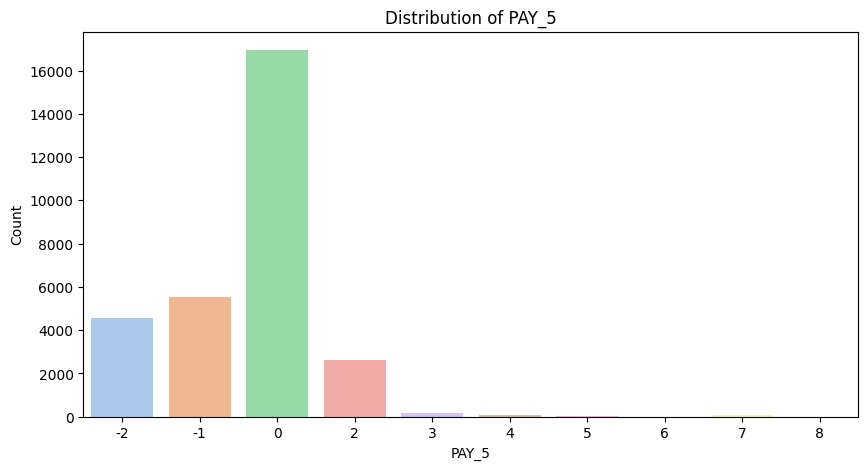

PAY_5
0     16947
-1     5539
-2     4546
2      2626
3       178
4        84
7        58
5        17
6         4
8         1
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3683513676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[column], palette='pastel')


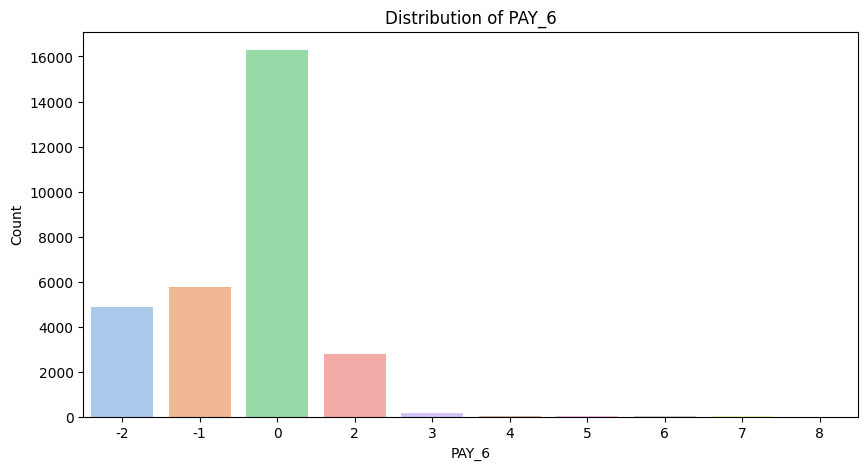

PAY_6
0     16286
-1     5740
-2     4895
2      2766
3       184
4        49
7        46
6        19
5        13
8         2
Name: count, dtype: int64


In [20]:
for col in cat_cols:
    cat_plotting_distribution(df, col)

we can see that most of the PAY_N columns have the less occurence classes, maybe i can identify the common for these 6 features the several common classes that appears less and turn them into one. For example from the graph it can be seen that between PAY_3 or PAY_4 to PAY_8 there a low occurence.

In the EDUCATION feature i will combine the classes such as "unknown"+"other" -> "other"

In [21]:
df['EDUCATION']=df['EDUCATION'].replace({'unknown': 'others'})

In [22]:
#the same for test_df
test_df['EDUCATION']=test_df['EDUCATION'].replace({'unknown': 'others'})

In [23]:
target='default.payment.next.month'

In [24]:
#here the function gives us the payment rate. If the 
# payment rate difference that is good sign
#  but to put final verdict we can use stats(p values)
#if it is less than 0.05, reject H0(the same distribution) and
#accept H1(there is a difference)
def wilson_ci(k, n, alpha=0.05):
    if n == 0:
        return (np.nan, np.nan)
    z = stats.norm.ppf(1 - alpha/2)   
    p = k / n
    denom = 1 + (z**2)/n
    center = (p + (z**2)/(2*n)) / denom
    half = (z * np.sqrt((p*(1-p) + (z**2)/(4*n)) / n)) / denom
    return (center - half, center + half)
def cat_vs_target(col, target=target, df=df, alpha=0.05, show_ci=True):

    tab = pd.crosstab(df[col], df[target])

    rate = df.groupby(col)[target].mean().sort_values(ascending=False)

    print(f"\n=== {col} ===")
    print("Payment rate:\n", rate)
    print("\nCrosstab:\n", tab)

    if show_ci:
        rows = []
        for cat in tab.index:
            n = int(tab.loc[cat].sum())
            k = int(tab.loc[cat, 1]) if 1 in tab.columns else 0
            r = k / n if n else np.nan
            lo, hi = wilson_ci(k, n, alpha=alpha)
            rows.append((cat, n, k, r, lo, hi))

        ci_df = pd.DataFrame(
            rows,
            columns=[col, "n", "survived_k", "payment_rate", f"ci{int((1-alpha)*100)}_lo", f"ci{int((1-alpha)*100)}_hi"]
        ).sort_values("payment_rate", ascending=False)

        print(f"\nPayment rate + {int((1-alpha)*100)}% CI (Wilson):")
        print(ci_df.to_string(index=False))
        # --- Chi-square 
        chi2, p_chi, dof, expected = stats.chi2_contingency(tab)

        if tab.shape == (2, 2) and expected.min() < 5:
            oddsratio, p = stats.fisher_exact(tab.values)
            print(f"\nFisher exact p-value: {p:.6f} | odds_ratio={oddsratio:.3f}")
        else:
            print(f"\nChi-square p-value: {p_chi:.6f} | dof={dof}")

        print(f"Expected values:\n{expected}")
        print("======" * 10)

In [25]:
for col in cat_cols:
    cat_vs_target(col)


=== SEX ===
Payment rate:
 SEX
male      0.241672
female    0.207763
Name: default.payment.next.month, dtype: float64

Crosstab:
 default.payment.next.month      0     1
SEX                                    
female                      14349  3763
male                         9015  2873

Payment rate + 95% CI (Wilson):
   SEX     n  survived_k  payment_rate  ci95_lo  ci95_hi
  male 11888        2873      0.241672 0.234061 0.249450
female 18112        3763      0.207763 0.201917 0.213733

Chi-square p-value: 0.000000 | dof=1
Expected values:
[[14105.6256  4006.3744]
 [ 9258.3744  2629.6256]]

=== EDUCATION ===
Payment rate:
 EDUCATION
high school        0.251576
university         0.237349
graduate school    0.192348
others             0.070513
Name: default.payment.next.month, dtype: float64

Crosstab:
 default.payment.next.month      0     1
EDUCATION                              
graduate school              8549  2036
high school                  3680  1237
others                

Right now looking at the payment rate for the features: PAY_N will be misleading because the low occured classes will appear as more likely, fe: for class 8 0: 0, 1:1 the payment rate will 100%:(, the same for p value. it can mislead.

About the Expected value, we want it to be more than 5, that show us te result is stable. if it is not for most classes maybe need some time to think about feat engi..

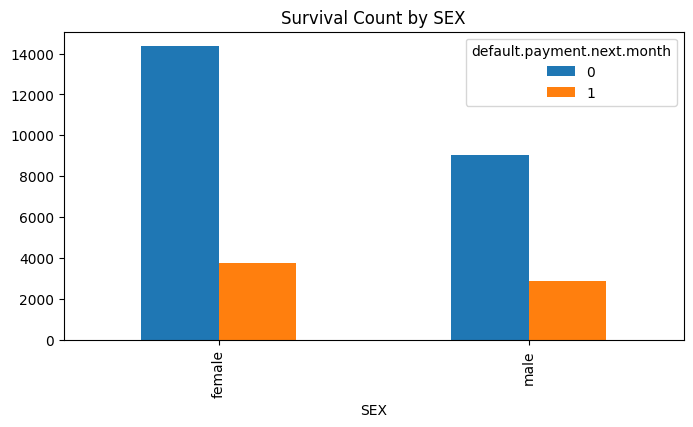

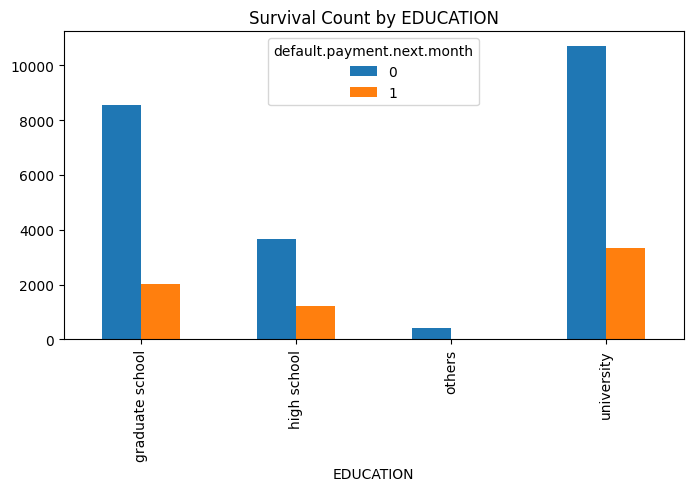

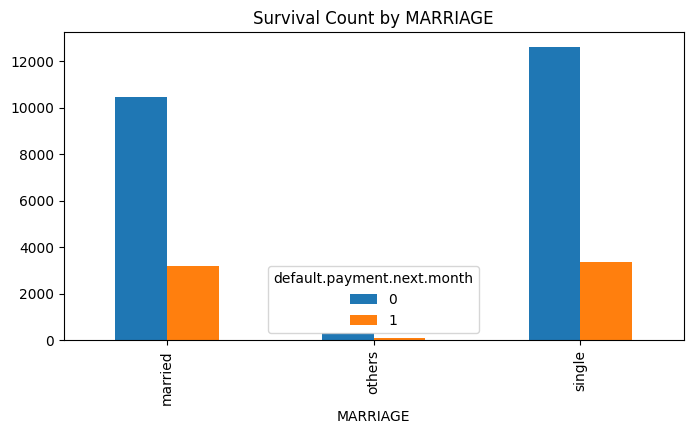

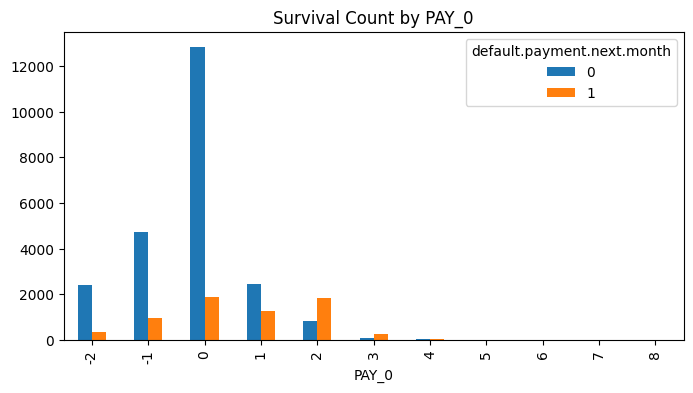

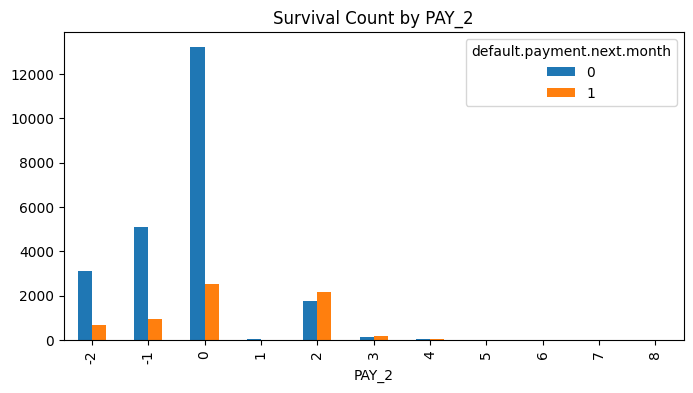

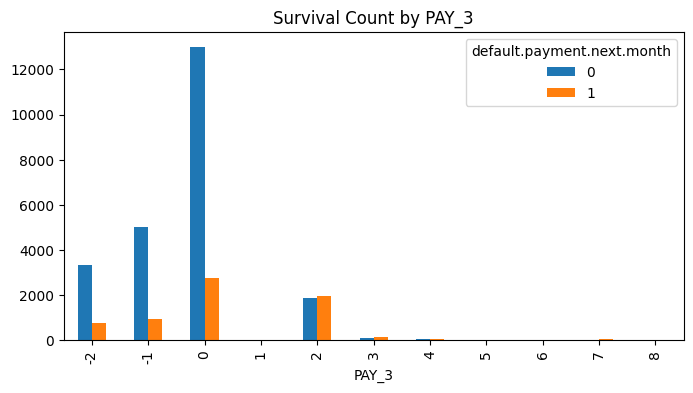

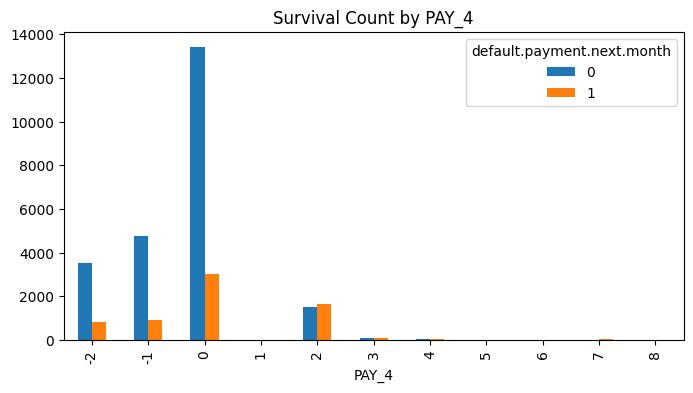

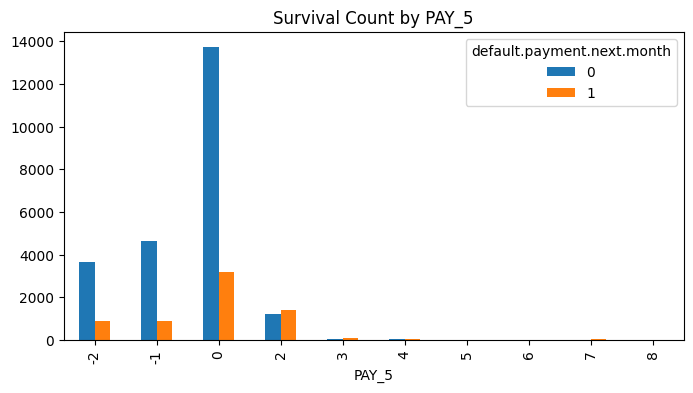

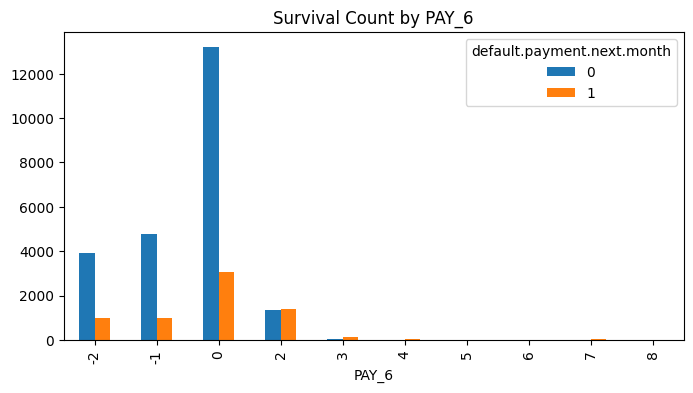

In [26]:
#to visually see it
for col in cat_cols:
    pd.pivot_table(df, index=col, 
                    aggfunc='count', 
                    columns='default.payment.next.month',
                    values='AGE' ,
                        observed=True).plot(kind='bar', figsize=(8, 4))
    plt.title(f'Survival Count by {col}')

from the visual we can see that for the feature PAY_N: the classes between 3 to 8, they occur much more less than others. What about the class 1 in the feat PAY_4?: there 2 reason: 1)it only occured less for this feat. and 2) since our feat will need ordinal encoder because these values have the logical order such -2>-1>0>...etc. and we can not just make 0 and last 5 classes into 1 our data will be mess as a result

In [27]:
# For the feature PAY_N, combining from 3 to 8 into 1 colume 
# fe called '3+'
PAY_N=[f'PAY_{z}' for z in range(2,7)]
PAY_N.append('PAY_0')
for col in PAY_N:
    df[col]=df[col].clip(upper=3)


In [28]:
#the same for test_df
for col in PAY_N:
    test_df[col]=test_df[col].clip(upper=3)

In [29]:
for col in PAY_N:
    cat_vs_target(col)


=== PAY_2 ===
Payment rate:
 PAY_2
 3    0.594203
 2    0.556150
-2    0.182708
 1    0.178571
-1    0.159669
 0    0.159123
Name: default.payment.next.month, dtype: float64

Crosstab:
 default.payment.next.month      0     1
PAY_2                                  
-2                           3091   691
-1                           5084   966
 0                          13227  2503
 1                             23     5
 2                           1743  2184
 3                            196   287

Payment rate + 95% CI (Wilson):
 PAY_2     n  survived_k  payment_rate  ci95_lo  ci95_hi
     3   483         287      0.594203 0.549834 0.637085
     2  3927        2184      0.556150 0.540563 0.571627
    -2  3782         691      0.182708 0.170716 0.195343
     1    28           5      0.178571 0.078785 0.355914
    -1  6050         966      0.159669 0.150656 0.169115
     0 15730        2503      0.159123 0.153490 0.164922

Chi-square p-value: 0.000000 | dof=5
Expected values:
[[2.94

Now the values are much better

In [30]:
def num_vs_target(
    col,
    target=target,
    show_effect=True,
    bins=50,
    plot=True,
    ci=True,
    n_boot=5000,
    alpha=0.05,
    seed=42
):
    sub = df[[col, target]].dropna()
    a = sub.loc[sub[target] == 0, col].astype(float).to_numpy()
    b = sub.loc[sub[target] == 1, col].astype(float).to_numpy()

    print(f"\n=== {col} ===")
    print(f"n(y=0)={len(a)} | n(y=1)={len(b)}")

    def desc(x):
        return {
            "mean": float(np.mean(x)),
            "median": float(np.median(x)),
            "std": float(np.std(x, ddof=1)),
            "min": float(np.min(x)),
            "q25": float(np.quantile(x, 0.25)),
            "q75": float(np.quantile(x, 0.75)),
            "max": float(np.max(x)),
        }

    da, db = desc(a), desc(b)
    print("y=0 stats:\n", {k: round(v, 4) for k, v in da.items()})
    print("y=1 stats:\n", {k: round(v, 4) for k, v in db.items()})

    # Tests
    u_stat, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")
    print(f"Mann–Whitney U: U={u_stat:.1f} | p-value={p_u:.6f}")

    t_stat, p_t = stats.ttest_ind(a, b, equal_var=False)  # Welch
    print(f"Welch t-test: t={t_stat:.3f} | p-value={p_t:.6f}")

    # Effect size (Cohen's d)
    d = None
    if show_effect:
        n1, n2 = len(a), len(b)
        s1, s2 = np.var(a, ddof=1), np.var(b, ddof=1)
        s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
        d = (np.mean(b) - np.mean(a)) / (s_pooled + 1e-12)
        print(f"Cohen's d (y=1 minus y=0): {d:.3f}")

    # --- Bootstrap CI function
    def bootstrap_ci(stat_func, a, b, n_boot, alpha, seed):
        rng = np.random.default_rng(seed)
        stats_arr = np.empty(n_boot, dtype=float)

        for i in range(n_boot):
            a_s = rng.choice(a, size=len(a), replace=True)
            b_s = rng.choice(b, size=len(b), replace=True)
            stats_arr[i] = stat_func(a_s, b_s)

        lo = float(np.quantile(stats_arr, alpha/2))
        hi = float(np.quantile(stats_arr, 1 - alpha/2))
        return (lo, hi)

    # --- Confidence intervals: median diff
    if ci:
        diff_med = float(np.median(b) - np.median(a))
        ci_med = bootstrap_ci(lambda a_s, b_s: np.median(b_s) - np.median(a_s),
                              a, b, n_boot, alpha, seed)
        print(f"Diff in medians (y=1 - y=0): {diff_med:.3f} | {int((1-alpha)*100)}% CI: [{ci_med[0]:.3f}, {ci_med[1]:.3f}]")

        # Difference in means (matches t-test idea)
        diff_mean = float(np.mean(b) - np.mean(a))
        ci_mean = bootstrap_ci(lambda a_s, b_s: np.mean(b_s) - np.mean(a_s),
                               a, b, n_boot, alpha, seed+1)
        print(f"Diff in means   (y=1 - y=0): {diff_mean:.3f} | {int((1-alpha)*100)}% CI: [{ci_mean[0]:.3f}, {ci_mean[1]:.3f}]")

        # Optional: CI for Cohen's d (can be unstable for heavy skew)
        if show_effect:
            def cohens_d(a_s, b_s):
                n1, n2 = len(a_s), len(b_s)
                s1, s2 = np.var(a_s, ddof=1), np.var(b_s, ddof=1)
                s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
                return (np.mean(b_s) - np.mean(a_s)) / (s_pooled + 1e-12)

            ci_d = bootstrap_ci(cohens_d, a, b, n_boot, alpha, seed+2)
            print(f"Cohen's d CI: {int((1-alpha)*100)}% CI: [{ci_d[0]:.3f}, {ci_d[1]:.3f}]")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].hist(a, bins=bins, alpha=0.5, label=f"{target}=0")
        axes[0].hist(b, bins=bins, alpha=0.5, label=f"{target}=1")
        axes[0].set_title(f"{col} histogram by {target}, bins={bins}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("count")
        axes[0].legend()

        axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)
        axes[1].set_title(f"{col} boxplot by {target}")
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()

    print("======" * 10)

In [31]:
num_cols.remove(target)

Now see the result of SS(statistical significance) for num->target

Mann–Whitney tests whether the distributions differ between the two groups, not assuming normality->is needed when the data is skewed or has outliers

Welch t-test checks whether the means differ between groups, allowing different variances->data is almost normalish, mislead if the data has big outliers

Cohen's d is optional but sometimes is needed make important decisions. it tells how big the difference: d= 0.2->small, 0.5->medium, 0.8->large

Null Hypo(H0)-> the distribution of feature does not differ for target class Alternative Hypo(H1)-> it differs

if p less than 0.05, we reject the H0, otherwise accept.


=== BILL_AMT6 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 39042.2687, 'median': 16679.0, 'std': 59547.0157, 'min': -209051.0, 'q25': 1265.5, 'q75': 49842.5, 'max': 961664.0}
y=1 stats:
 {'mean': 38271.4355, 'median': 18028.5, 'std': 59579.6743, 'min': -339603.0, 'q25': 1150.0, 'q75': 47424.0, 'max': 514975.0}
Mann–Whitney U: U=77529951.0 | p-value=0.989481
Welch t-test: t=0.930 | p-value=0.352283
Cohen's d (y=1 minus y=0): -0.013
Diff in medians (y=1 - y=0): 1349.500 | 95% CI: [496.475, 2266.062]
Diff in means   (y=1 - y=0): -770.833 | 95% CI: [-2361.882, 872.683]
Cohen's d CI: 95% CI: [-0.040, 0.015]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


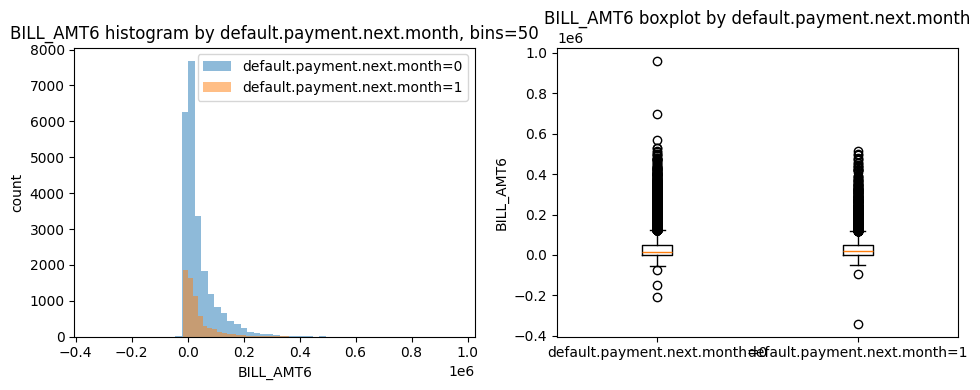


=== BILL_AMT2 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 49717.4357, 'median': 21660.5, 'std': 71029.9467, 'min': -69777.0, 'q25': 3055.0, 'q75': 65686.0, 'max': 983931.0}
y=1 stats:
 {'mean': 47283.6178, 'median': 20300.5, 'std': 71651.0304, 'min': -17710.0, 'q25': 2694.0, 'q75': 57919.75, 'max': 581775.0}
Mann–Whitney U: U=79198493.0 | p-value=0.007061
Welch t-test: t=2.447 | p-value=0.014437
Cohen's d (y=1 minus y=0): -0.034
Diff in medians (y=1 - y=0): -1360.000 | 95% CI: [-2514.012, -51.463]
Diff in means   (y=1 - y=0): -2433.818 | 95% CI: [-4354.573, -516.361]
Cohen's d CI: 95% CI: [-0.061, -0.006]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


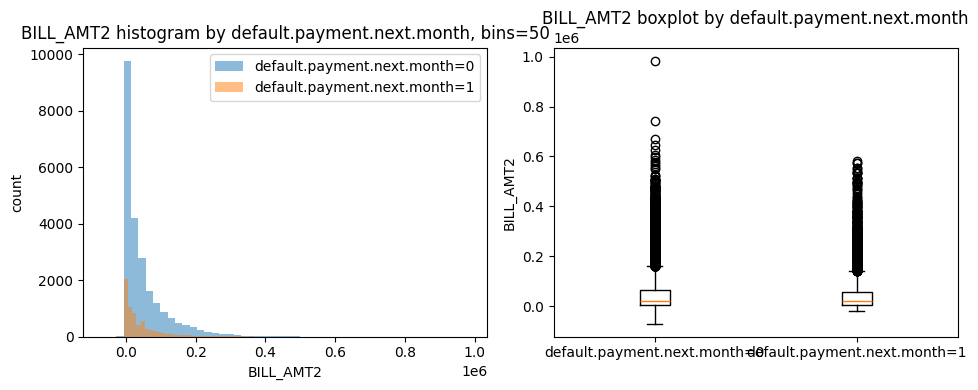


=== PAY_AMT2 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6640.4651, 'median': 2247.5, 'std': 25302.2636, 'min': 0.0, 'q25': 1005.0, 'q75': 5311.25, 'max': 1684259.0}
y=1 stats:
 {'mean': 3388.6496, 'median': 1533.5, 'std': 11737.9861, 'min': 0.0, 'q25': 0.0, 'q75': 3309.75, 'max': 358689.0}
Mann–Whitney U: U=93753756.0 | p-value=0.000000
Welch t-test: t=14.817 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.141
Diff in medians (y=1 - y=0): -714.000 | 95% CI: [-800.000, -607.000]
Diff in means   (y=1 - y=0): -3251.815 | 95% CI: [-3686.682, -2838.132]
Cohen's d CI: 95% CI: [-0.174, -0.118]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


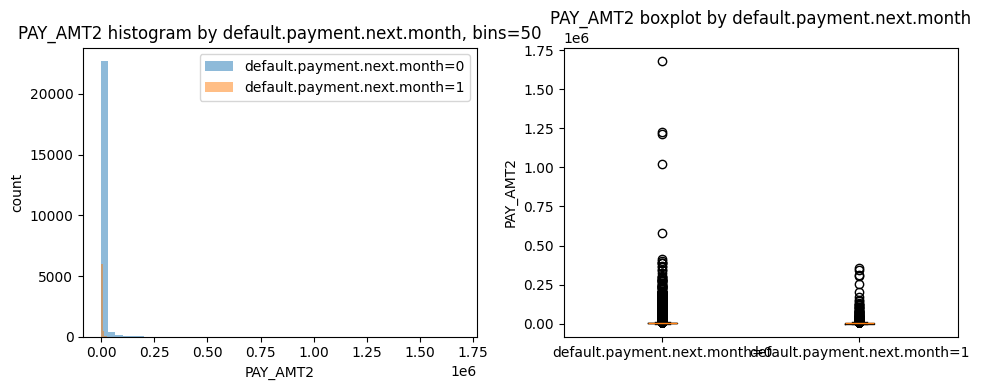


=== LIMIT_BAL ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 178099.7261, 'median': 150000.0, 'std': 131628.3597, 'min': 10000.0, 'q25': 70000.0, 'q75': 250000.0, 'max': 1000000.0}
y=1 stats:
 {'mean': 130109.6564, 'median': 90000.0, 'std': 115378.5406, 'min': 10000.0, 'q25': 50000.0, 'q75': 200000.0, 'max': 740000.0}
Mann–Whitney U: U=95786286.5 | p-value=0.000000
Welch t-test: t=28.952 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.374
Diff in medians (y=1 - y=0): -60000.000 | 95% CI: [-70000.000, -60000.000]
Diff in means   (y=1 - y=0): -47990.070 | 95% CI: [-51169.717, -44702.105]
Cohen's d CI: 95% CI: [-0.399, -0.349]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


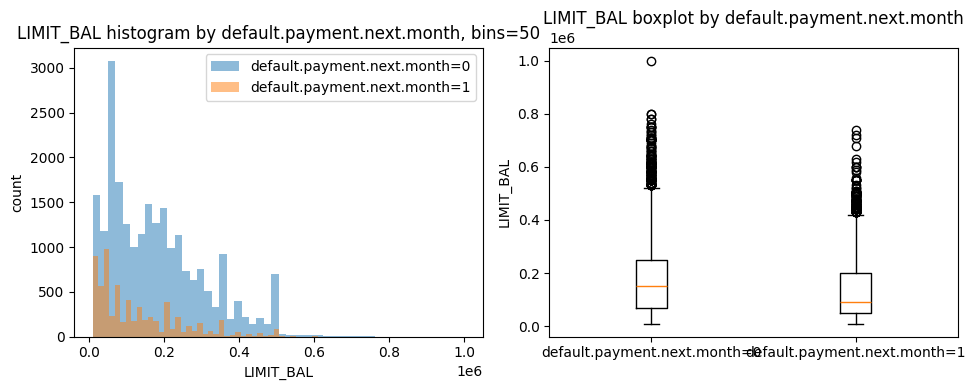


=== PAY_AMT4 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 5300.5293, 'median': 1734.0, 'std': 16689.7781, 'min': 0.0, 'q25': 390.0, 'q75': 4602.0, 'max': 621000.0}
y=1 stats:
 {'mean': 3155.6267, 'median': 1000.0, 'std': 11191.9732, 'min': 0.0, 'q25': 0.0, 'q75': 2939.25, 'max': 432130.0}
Mann–Whitney U: U=91253295.5 | p-value=0.000000
Welch t-test: t=12.222 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.137
Diff in medians (y=1 - y=0): -734.000 | 95% CI: [-800.000, -683.000]
Diff in means   (y=1 - y=0): -2144.903 | 95% CI: [-2483.146, -1791.706]
Cohen's d CI: 95% CI: [-0.158, -0.115]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


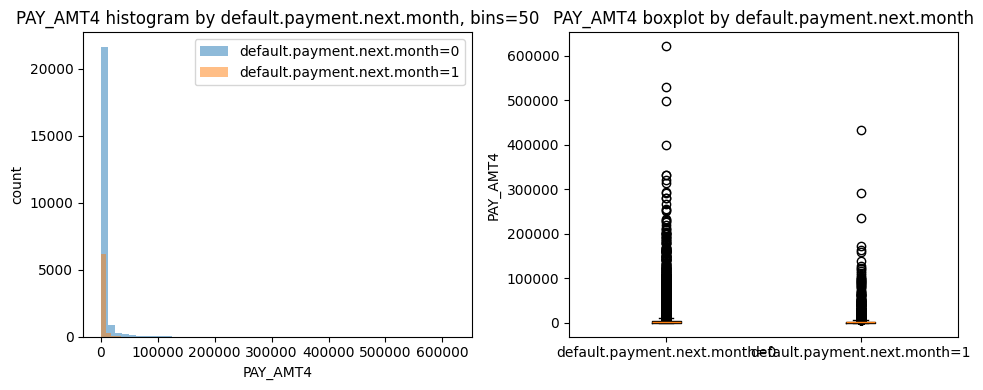


=== PAY_AMT1 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6307.3374, 'median': 2459.5, 'std': 18014.509, 'min': 0.0, 'q25': 1163.75, 'q75': 5606.25, 'max': 873552.0}
y=1 stats:
 {'mean': 3397.0442, 'median': 1636.0, 'std': 9544.2524, 'min': 0.0, 'q25': 0.0, 'q75': 3478.25, 'max': 300000.0}
Mann–Whitney U: U=94780733.0 | p-value=0.000000
Welch t-test: t=17.513 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.176
Diff in medians (y=1 - y=0): -823.500 | 95% CI: [-900.000, -700.000]
Diff in means   (y=1 - y=0): -2910.293 | 95% CI: [-3241.789, -2579.651]
Cohen's d CI: 95% CI: [-0.198, -0.156]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


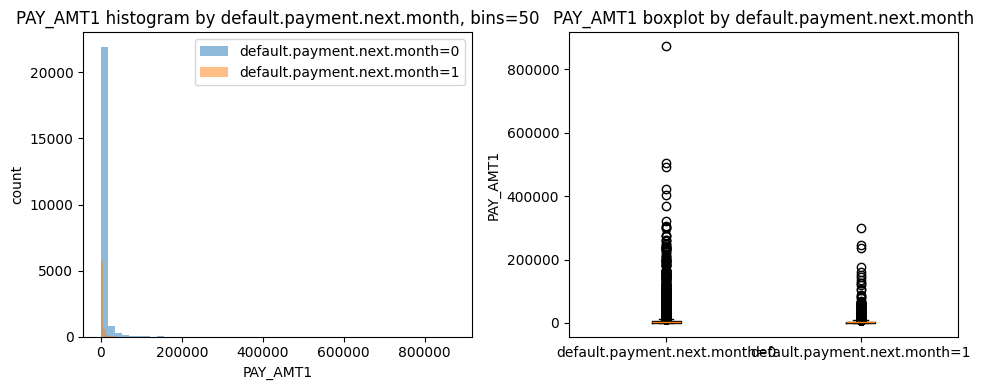


=== AGE ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 35.4173, 'median': 34.0, 'std': 9.0774, 'min': 21.0, 'q25': 28.0, 'q75': 41.0, 'max': 79.0}
y=1 stats:
 {'mean': 35.7257, 'median': 34.0, 'std': 9.6934, 'min': 21.0, 'q25': 28.0, 'q75': 42.0, 'max': 75.0}
Mann–Whitney U: U=76966879.5 | p-value=0.372504
Welch t-test: t=-2.320 | p-value=0.020386
Cohen's d (y=1 minus y=0): 0.033
Diff in medians (y=1 - y=0): 0.000 | 95% CI: [0.000, 1.000]
Diff in means   (y=1 - y=0): 0.308 | 95% CI: [0.045, 0.573]
Cohen's d CI: 95% CI: [0.005, 0.061]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


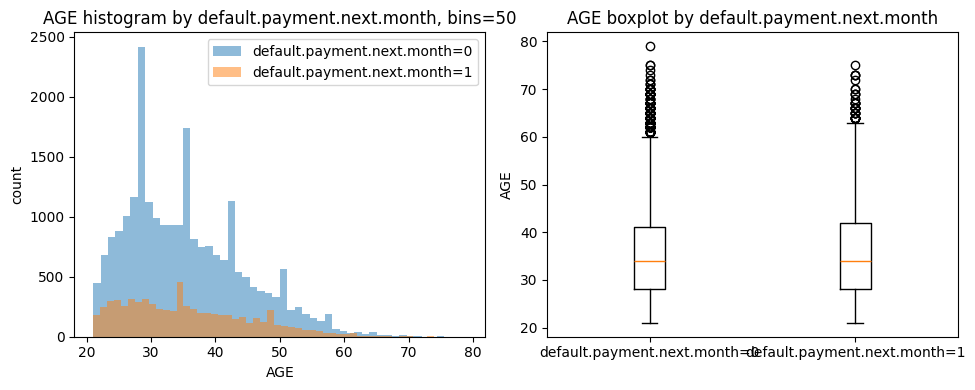


=== BILL_AMT1 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 51994.2273, 'median': 23119.5, 'std': 73577.6067, 'min': -165580.0, 'q25': 3677.25, 'q75': 69027.0, 'max': 964511.0}
y=1 stats:
 {'mean': 48509.1623, 'median': 20185.0, 'std': 73782.0672, 'min': -6676.0, 'q25': 2987.75, 'q75': 59626.5, 'max': 613860.0}
Mann–Whitney U: U=80252445.5 | p-value=0.000012
Welch t-test: t=3.398 | p-value=0.000682
Cohen's d (y=1 minus y=0): -0.047
Diff in medians (y=1 - y=0): -2934.500 | 95% CI: [-4264.163, -1431.950]
Diff in means   (y=1 - y=0): -3485.065 | 95% CI: [-5419.868, -1472.045]
Cohen's d CI: 95% CI: [-0.074, -0.020]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


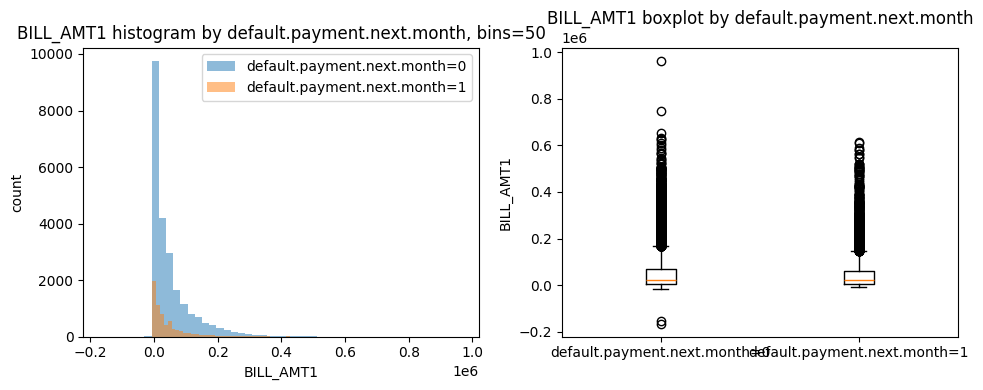


=== BILL_AMT5 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 40530.4453, 'median': 17998.0, 'std': 60617.2681, 'min': -81334.0, 'q25': 1823.0, 'q75': 51135.25, 'max': 927171.0}
y=1 stats:
 {'mean': 39540.1905, 'median': 18478.5, 'std': 61424.6959, 'min': -53007.0, 'q25': 1502.75, 'q75': 47853.0, 'max': 547880.0}
Mann–Whitney U: U=78259960.0 | p-value=0.235367
Welch t-test: t=1.162 | p-value=0.245129
Cohen's d (y=1 minus y=0): -0.016
Diff in medians (y=1 - y=0): 480.500 | 95% CI: [-191.000, 1234.500]
Diff in means   (y=1 - y=0): -990.255 | 95% CI: [-2610.123, 699.218]
Cohen's d CI: 95% CI: [-0.043, 0.011]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


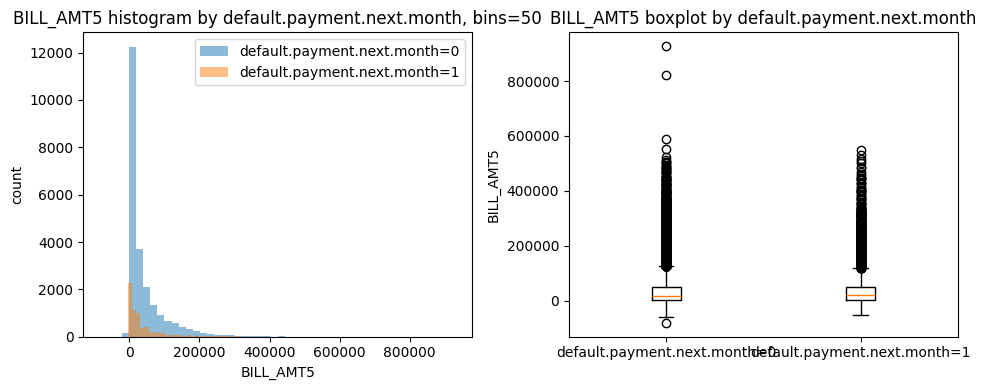


=== BILL_AMT4 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 43611.1653, 'median': 19000.0, 'std': 64324.7967, 'min': -170000.0, 'q25': 2360.0, 'q75': 55988.0, 'max': 891586.0}
y=1 stats:
 {'mean': 42036.9506, 'median': 19119.5, 'std': 64351.0761, 'min': -65167.0, 'q25': 2141.5, 'q75': 50175.75, 'max': 548020.0}
Mann–Whitney U: U=78422386.5 | p-value=0.147768
Welch t-test: t=1.759 | p-value=0.078642
Cohen's d (y=1 minus y=0): -0.024
Diff in medians (y=1 - y=0): 119.500 | 95% CI: [-503.000, 704.000]
Diff in means   (y=1 - y=0): -1574.215 | 95% CI: [-3311.876, 157.699]
Cohen's d CI: 95% CI: [-0.051, 0.003]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


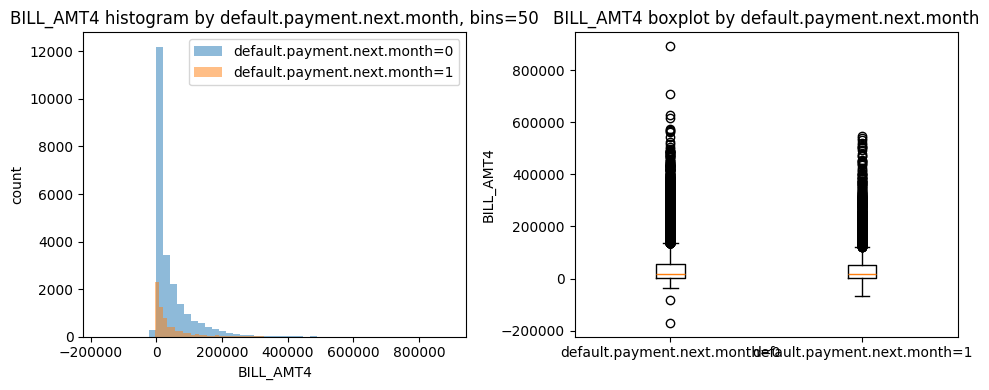


=== PAY_AMT5 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 5248.2203, 'median': 1765.0, 'std': 16071.6679, 'min': 0.0, 'q25': 369.0, 'q75': 4600.0, 'max': 426529.0}
y=1 stats:
 {'mean': 3219.1395, 'median': 1000.0, 'std': 11944.7312, 'min': 0.0, 'q25': 0.0, 'q75': 3000.0, 'max': 332000.0}
Mann–Whitney U: U=90022048.0 | p-value=0.000000
Welch t-test: t=11.246 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.133
Diff in medians (y=1 - y=0): -765.000 | 95% CI: [-830.000, -697.500]
Diff in means   (y=1 - y=0): -2029.081 | 95% CI: [-2386.920, -1655.626]
Cohen's d CI: 95% CI: [-0.156, -0.109]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


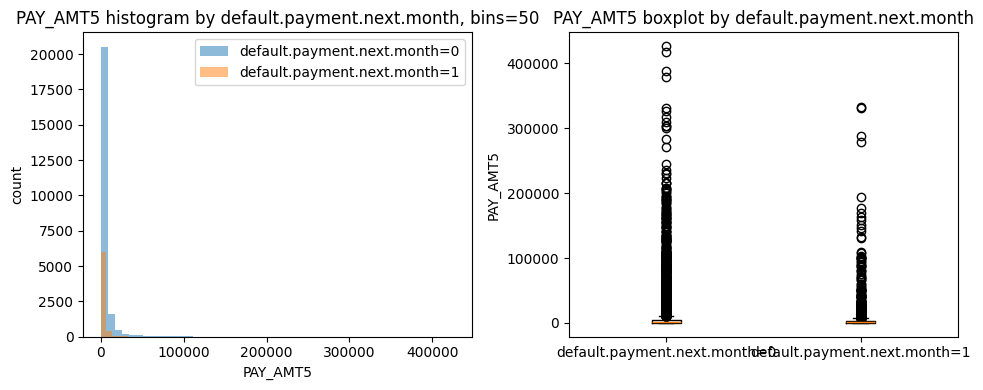


=== PAY_AMT6 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 5719.3718, 'median': 1706.0, 'std': 18792.9505, 'min': 0.0, 'q25': 300.0, 'q75': 4545.0, 'max': 528666.0}
y=1 stats:
 {'mean': 3441.4821, 'median': 1000.0, 'std': 13464.0059, 'min': 0.0, 'q25': 0.0, 'q75': 2974.5, 'max': 345293.0}
Mann–Whitney U: U=90526299.0 | p-value=0.000000
Welch t-test: t=11.058 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.128
Diff in medians (y=1 - y=0): -706.000 | 95% CI: [-795.000, -657.988]
Diff in means   (y=1 - y=0): -2277.890 | 95% CI: [-2664.483, -1863.084]
Cohen's d CI: 95% CI: [-0.150, -0.106]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


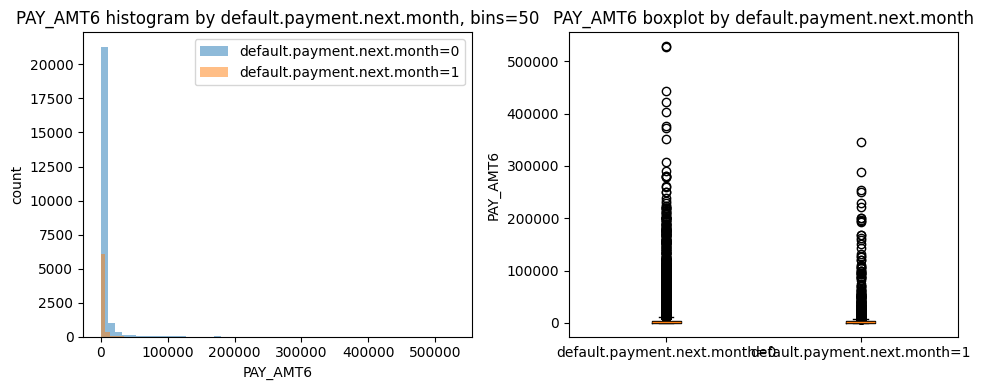


=== PAY_AMT3 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 5753.4968, 'median': 2000.0, 'std': 18684.2559, 'min': 0.0, 'q25': 600.0, 'q75': 5000.0, 'max': 896040.0}
y=1 stats:
 {'mean': 3367.3516, 'median': 1222.0, 'std': 12959.6245, 'min': 0.0, 'q25': 0.0, 'q75': 3000.0, 'max': 508229.0}
Mann–Whitney U: U=92491959.5 | p-value=0.000000
Welch t-test: t=11.893 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.136
Diff in medians (y=1 - y=0): -778.000 | 95% CI: [-805.500, -700.000]
Diff in means   (y=1 - y=0): -2386.145 | 95% CI: [-2752.562, -1970.549]
Cohen's d CI: 95% CI: [-0.162, -0.112]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


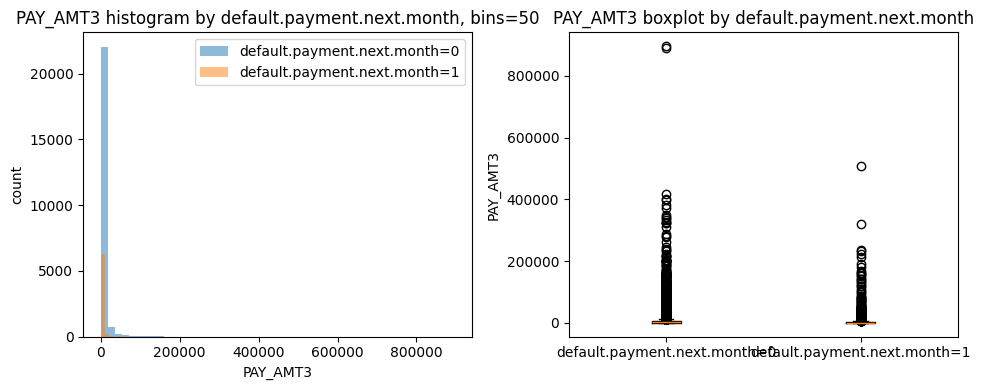


=== BILL_AMT3 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 47533.3656, 'median': 20202.5, 'std': 69576.661, 'min': -157264.0, 'q25': 2769.75, 'q75': 61894.0, 'max': 1664089.0}
y=1 stats:
 {'mean': 45181.5989, 'median': 19834.5, 'std': 68516.9757, 'min': -61506.0, 'q25': 2500.0, 'q75': 54733.75, 'max': 578971.0}
Mann–Whitney U: U=78887405.5 | p-value=0.028203
Welch t-test: t=2.459 | p-value=0.013945
Cohen's d (y=1 minus y=0): -0.034
Diff in medians (y=1 - y=0): -368.000 | 95% CI: [-1177.013, 555.525]
Diff in means   (y=1 - y=0): -2351.767 | 95% CI: [-4184.318, -501.228]
Cohen's d CI: 95% CI: [-0.060, -0.007]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


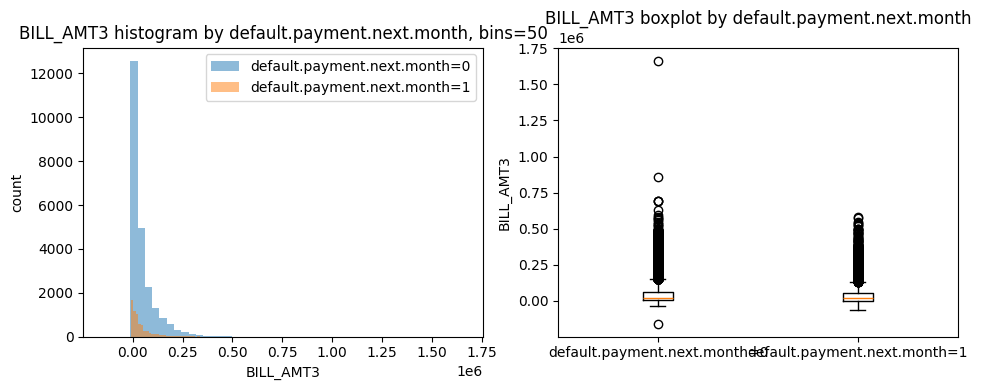

In [32]:
for col in num_cols:
    num_vs_target(col=col)

```From here we can see that:```

>PAY_AMT:
    1-6->the mean and distribution differ can be seen visually and statistically

>BIL_AMT:
    1-2->the mean and distribution differ can be seen visually and statistically
    3-although the mann-whitney test is a little bit more that 0.05 it still does not pass. hypo: do not differ
    5-6->do not differ 
    4-here the mann-whitney shows 0.18 meaning that we can not reject the H0, but the Welch t-test shows less than 0.05, the question what must me done in this situation? the answer is on what we look at.fe welch t-test look at difference in mean, while the Mann-Whitney looks at the difference in overall distribution. in our case the info about the mean is not very important. therefore verdict is do not differ

>Age: 
    do not differ. maybe i can try grouping it. important from the distribtion it can be seen that the graph starts from 20 value, therefore we need to cut based on the our case

>LIMIT_BAL:
    it differ. needs np.log1p


>One important thing to mention is that it is not really recomended to features that seem to have connections or orders: such as BIL_AMT and PAY_AMT. Although models like tree may not really be affected with the remove of these kinda features it still better to leave them as they are, since they give info how the data being changed over time

```But AGE is not the case```

In [33]:
bins   = [21, 25, 35, 45, 55, 65, np.inf]
labels = ["21-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df['AGE_BIN']=pd.cut(df['AGE'], bins=bins, labels=labels, right=False)

In [34]:
df['LIMIT_BAL_LOG']=np.log1p(df["LIMIT_BAL"])
test_df['LIMIT_BAL_LOG']=np.log1p(test_df["LIMIT_BAL"])

for now i can not check the change it gave, but after i declare the function cat_vs_target i am gonna check, the importance of Cramer's V

In [35]:
PAY_AMT=[f'PAY_AMT{i}' for i in range(1,7)]#no negative value
BILL_AMT=[f'BILL_AMT{i}' for i in range(1,7)]#has the negative value


In [36]:
#since the BILL_AMT has the negatives i am gonna use 
# method of yeo-johnson that is quite similar for cox-box, 
#but it takes the negative value
pt=PowerTransformer(method='yeo-johnson', standardize=False)

df[BILL_AMT]=pt.fit_transform(df[BILL_AMT])

#here it is important to 
#change the test_df based on the tranformation from the train
test_df[BILL_AMT]=pt.transform(test_df[BILL_AMT])

for BILL_AMT columns we need to standardscaler after in the pipeline

min values: -707758.8137291954

=== BILL_AMT1 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 13064.2977, 'median': 7123.708, 'std': 17650.0729, 'min': -707758.8137, 'q25': 1441.3359, 'q75': 18428.2852, 'max': 182224.2939}
y=1 stats:
 {'mean': 12295.5541, 'median': 6331.1168, 'std': 16329.1211, 'min': -18731.7881, 'q25': 1203.2806, 'q75': 16227.0602, 'max': 123055.4268}
Mann–Whitney U: U=80252445.5 | p-value=0.000012
Welch t-test: t=3.323 | p-value=0.000893
Cohen's d (y=1 minus y=0): -0.044
Diff in medians (y=1 - y=0): -792.591 | 95% CI: [-1151.722, -385.735]
Diff in means   (y=1 - y=0): -768.744 | 95% CI: [-1211.161, -323.006]
Cohen's d CI: 95% CI: [-0.071, -0.018]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


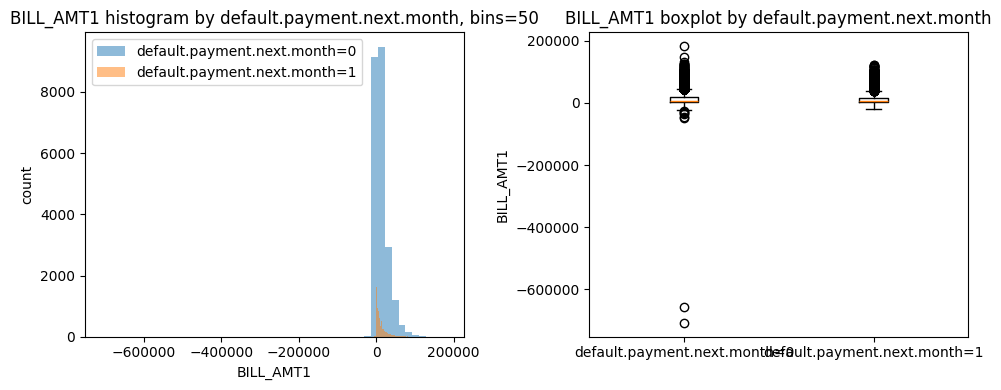

min values: -383594.1671751692

=== BILL_AMT2 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 8649.045, 'median': 4923.8767, 'std': 11577.3494, 'min': -383594.1672, 'q25': 961.7383, 'q75': 12413.1894, 'max': 118451.6266}
y=1 stats:
 {'mean': 8322.5911, 'median': 4664.8011, 'std': 10744.8549, 'min': -77476.7655, 'q25': 865.963, 'q75': 11177.348, 'max': 76445.9984}
Mann–Whitney U: U=79198493.0 | p-value=0.007061
Welch t-test: t=2.146 | p-value=0.031870
Cohen's d (y=1 minus y=0): -0.029
Diff in medians (y=1 - y=0): -259.076 | 95% CI: [-477.991, -9.841]
Diff in means   (y=1 - y=0): -326.454 | 95% CI: [-619.872, -32.013]
Cohen's d CI: 95% CI: [-0.055, -0.003]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


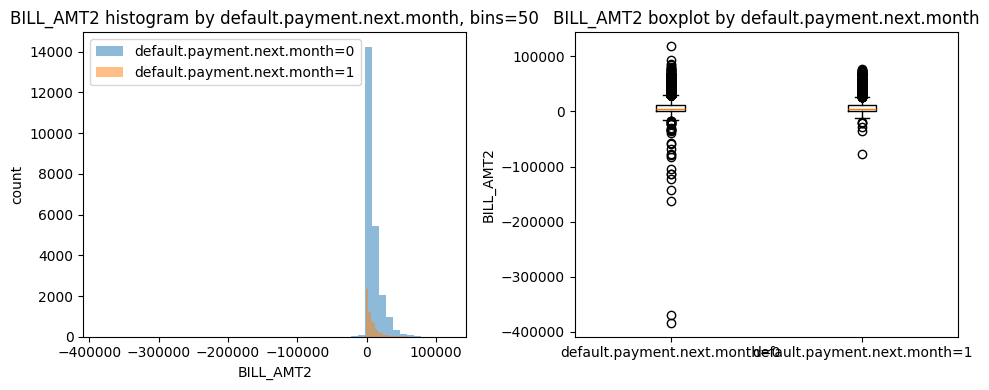

min values: -755807.5682141102

=== BILL_AMT3 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 10710.8377, 'median': 5744.8471, 'std': 14735.0343, 'min': -755807.5682, 'q25': 1044.3535, 'q75': 15009.4046, 'max': 252622.5366}
y=1 stats:
 {'mean': 10201.6015, 'median': 5654.9633, 'std': 14217.4082, 'min': -258630.2132, 'q25': 956.4232, 'q75': 13507.2179, 'max': 102142.0824}
Mann–Whitney U: U=78887405.5 | p-value=0.028203
Welch t-test: t=2.554 | p-value=0.010661
Cohen's d (y=1 minus y=0): -0.035
Diff in medians (y=1 - y=0): -89.884 | 95% CI: [-287.562, 135.399]
Diff in means   (y=1 - y=0): -509.236 | 95% CI: [-893.693, -124.193]
Cohen's d CI: 95% CI: [-0.062, -0.008]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


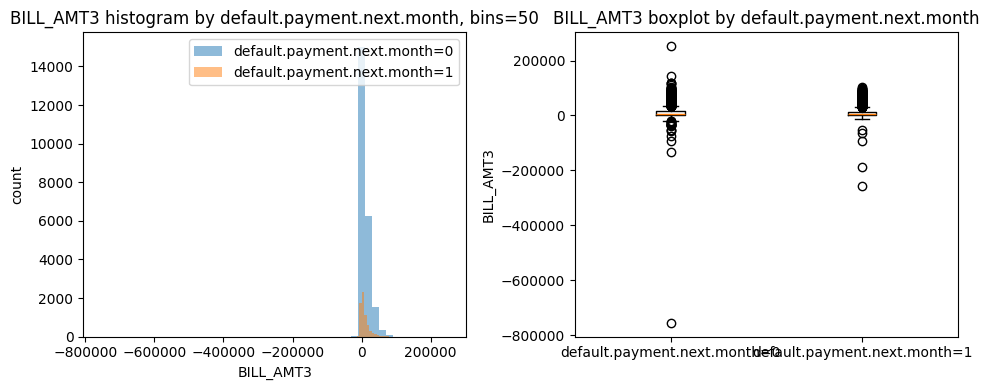

min values: -743715.9285242059

=== BILL_AMT4 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 10926.4471, 'median': 5915.0318, 'std': 15380.9065, 'min': -743715.9285, 'q25': 968.7537, 'q75': 15099.3888, 'max': 166452.9526}
y=1 stats:
 {'mean': 10529.4202, 'median': 5947.281, 'std': 15017.0136, 'min': -250983.6202, 'q25': 890.4264, 'q75': 13730.367, 'max': 109147.781}
Mann–Whitney U: U=78422386.5 | p-value=0.147768
Welch t-test: t=1.890 | p-value=0.058728
Cohen's d (y=1 minus y=0): -0.026
Diff in medians (y=1 - y=0): 32.249 | 95% CI: [-135.707, 189.837]
Diff in means   (y=1 - y=0): -397.027 | 95% CI: [-795.427, 11.114]
Cohen's d CI: 95% CI: [-0.053, 0.002]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


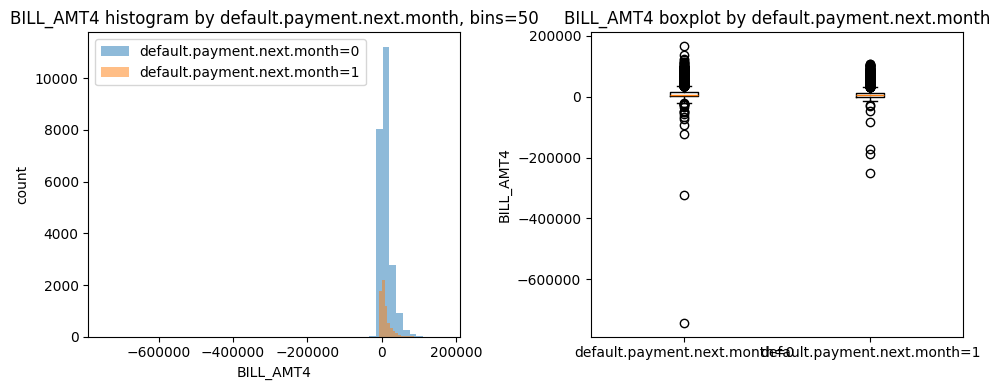

min values: -403674.6074504207

=== BILL_AMT5 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 8184.8449, 'median': 4688.0574, 'std': 11505.2353, 'min': -403674.6075, 'q25': 675.491, 'q75': 11337.6706, 'max': 131433.0939}
y=1 stats:
 {'mean': 7987.793, 'median': 4793.6976, 'std': 11687.4602, 'min': -246256.5088, 'q25': 573.5628, 'q75': 10719.1099, 'max': 84237.0355}
Mann–Whitney U: U=78259960.0 | p-value=0.235367
Welch t-test: t=1.216 | p-value=0.223922
Cohen's d (y=1 minus y=0): -0.017
Diff in medians (y=1 - y=0): 105.640 | 95% CI: [-42.006, 271.371]
Diff in means   (y=1 - y=0): -197.052 | 95% CI: [-510.490, 118.738]
Cohen's d CI: 95% CI: [-0.045, 0.011]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


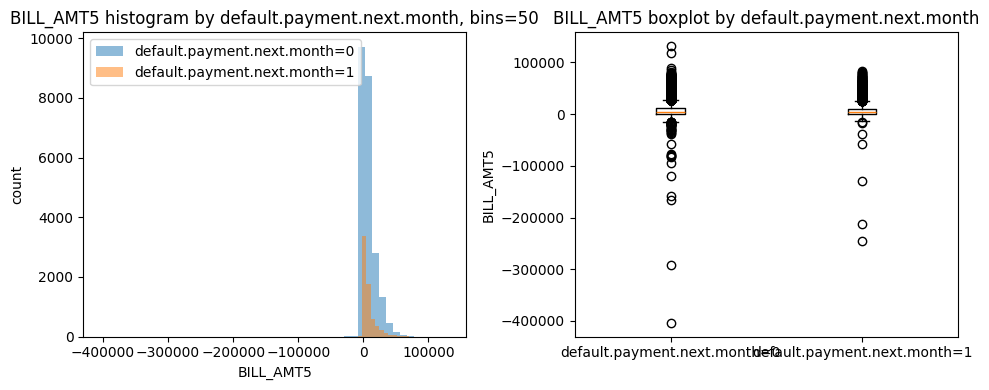

min values: -1045545.234332157

=== BILL_AMT6 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 14449.5735, 'median': 7288.9664, 'std': 21143.6371, 'min': -614482.7777, 'q25': 706.8611, 'q75': 19621.7971, 'max': 285414.5071}
y=1 stats:
 {'mean': 14089.645, 'median': 7820.4694, 'std': 24391.287, 'min': -1045545.2343, 'q25': 648.1972, 'q75': 18758.5139, 'max': 162229.2538}
Mann–Whitney U: U=77529951.0 | p-value=0.989481
Welch t-test: t=1.091 | p-value=0.275186
Cohen's d (y=1 minus y=0): -0.016
Diff in medians (y=1 - y=0): 531.503 | 95% CI: [195.496, 892.276]
Diff in means   (y=1 - y=0): -359.929 | 95% CI: [-1034.941, 281.883]
Cohen's d CI: 95% CI: [-0.045, 0.013]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


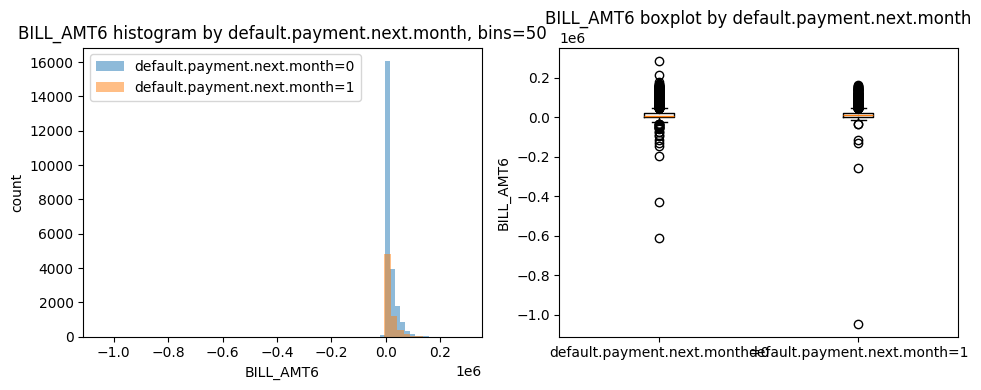

In [37]:
for col in BILL_AMT:
    print(f"min values: {df[col].min()}")
    num_vs_target(col)


In [38]:
df[PAY_AMT]=np.log1p(df[PAY_AMT])
test_df[PAY_AMT]=np.log1p(test_df[PAY_AMT])

min values: 0.0

=== PAY_AMT1 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6.925, 'median': 7.8081, 'std': 3.059, 'min': 0.0, 'q25': 7.0603, 'q75': 8.6318, 'max': 13.6803}
y=1 stats:
 {'mean': 5.5914, 'median': 7.4006, 'std': 3.6647, 'min': 0.0, 'q25': 0.0, 'q75': 8.1546, 'max': 12.6115}
Mann–Whitney U: U=94780733.0 | p-value=0.000000
Welch t-test: t=27.085 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.416
Diff in medians (y=1 - y=0): -0.408 | 95% CI: [-0.446, -0.345]
Diff in means   (y=1 - y=0): -1.334 | 95% CI: [-1.430, -1.235]
Cohen's d CI: 95% CI: [-0.447, -0.386]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


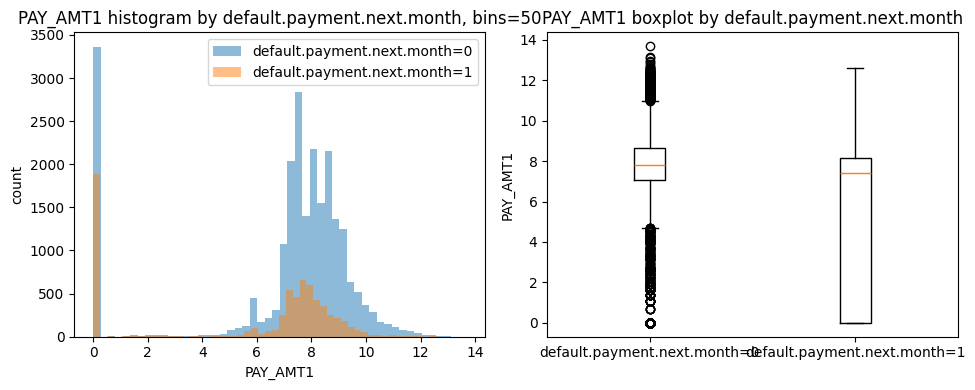

min values: 0.0

=== PAY_AMT2 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6.8248, 'median': 7.718, 'std': 3.1343, 'min': 0.0, 'q25': 6.9137, 'q75': 8.5778, 'max': 14.3368}
y=1 stats:
 {'mean': 5.6397, 'median': 7.336, 'std': 3.5945, 'min': 0.0, 'q25': 0.0, 'q75': 8.1049, 'max': 12.7902}
Mann–Whitney U: U=93753756.0 | p-value=0.000000
Welch t-test: t=24.357 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.366
Diff in medians (y=1 - y=0): -0.382 | 95% CI: [-0.427, -0.321]
Diff in means   (y=1 - y=0): -1.185 | 95% CI: [-1.279, -1.089]
Cohen's d CI: 95% CI: [-0.395, -0.336]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


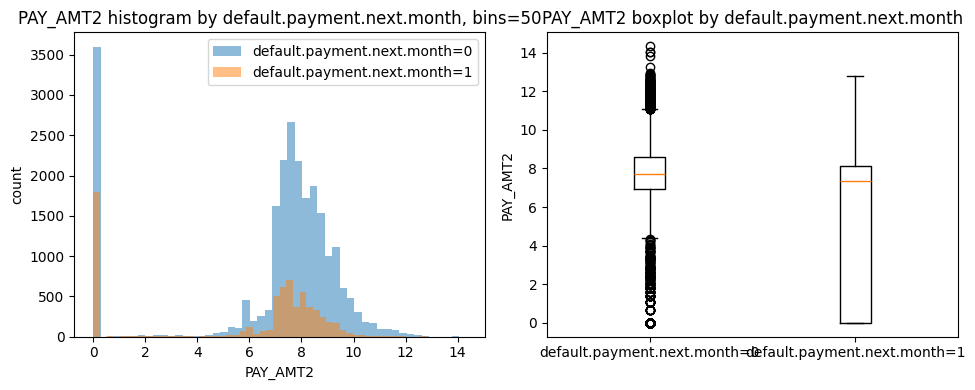

min values: 0.0

=== PAY_AMT3 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6.5317, 'median': 7.6014, 'std': 3.2254, 'min': 0.0, 'q25': 6.3986, 'q75': 8.5174, 'max': 13.7057}
y=1 stats:
 {'mean': 5.4083, 'median': 7.1091, 'std': 3.6219, 'min': 0.0, 'q25': 0.0, 'q75': 8.0067, 'max': 13.1387}
Mann–Whitney U: U=92491959.5 | p-value=0.000000
Welch t-test: t=22.826 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.339
Diff in medians (y=1 - y=0): -0.492 | 95% CI: [-0.515, -0.431]
Diff in means   (y=1 - y=0): -1.123 | 95% CI: [-1.218, -1.027]
Cohen's d CI: 95% CI: [-0.368, -0.310]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


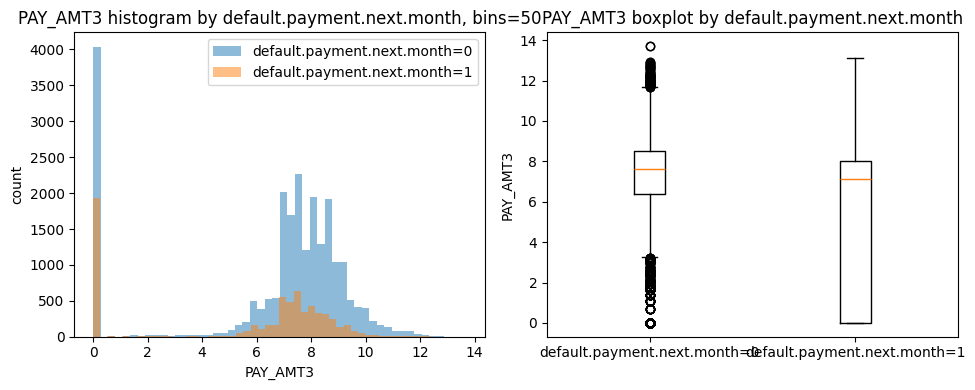

min values: 0.0

=== PAY_AMT4 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6.3059, 'median': 7.4588, 'std': 3.2954, 'min': 0.0, 'q25': 5.9687, 'q75': 8.4345, 'max': 13.3391}
y=1 stats:
 {'mean': 5.2744, 'median': 6.9088, 'std': 3.6185, 'min': 0.0, 'q25': 0.0, 'q75': 7.9862, 'max': 12.9765}
Mann–Whitney U: U=91253295.5 | p-value=0.000000
Welch t-test: t=20.890 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.306
Diff in medians (y=1 - y=0): -0.550 | 95% CI: [-0.587, -0.520]
Diff in means   (y=1 - y=0): -1.031 | 95% CI: [-1.127, -0.934]
Cohen's d CI: 95% CI: [-0.336, -0.278]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


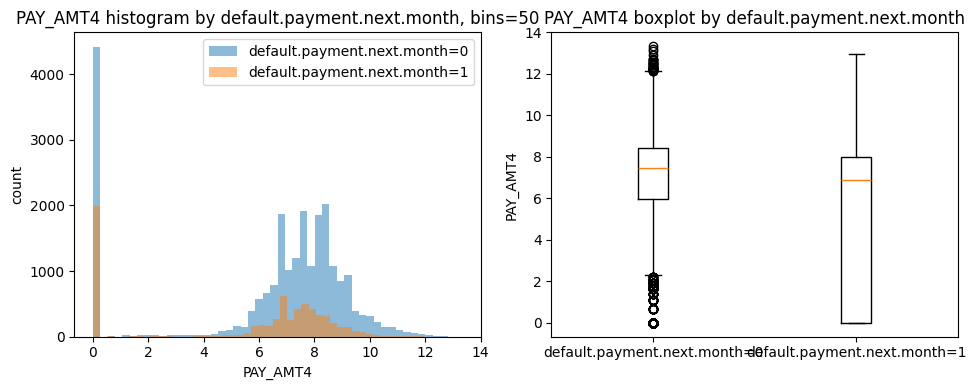

min values: 0.0

=== PAY_AMT5 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6.2338, 'median': 7.4765, 'std': 3.3678, 'min': 0.0, 'q25': 5.9135, 'q75': 8.434, 'max': 12.9634}
y=1 stats:
 {'mean': 5.3225, 'median': 6.9088, 'std': 3.6116, 'min': 0.0, 'q25': 0.0, 'q75': 8.0067, 'max': 12.7129}
Mann–Whitney U: U=90022048.0 | p-value=0.000000
Welch t-test: t=18.407 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.266
Diff in medians (y=1 - y=0): -0.568 | 95% CI: [-0.604, -0.526]
Diff in means   (y=1 - y=0): -0.911 | 95% CI: [-1.009, -0.815]
Cohen's d CI: 95% CI: [-0.295, -0.237]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


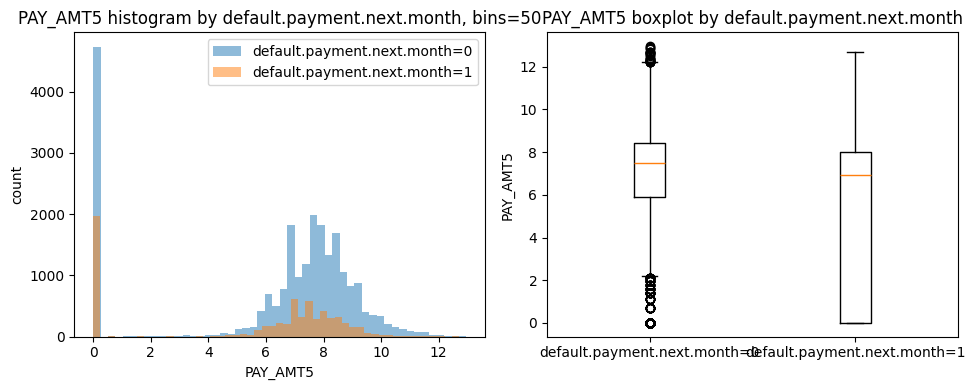

min values: 0.0

=== PAY_AMT6 ===
n(y=0)=23364 | n(y=1)=6636
y=0 stats:
 {'mean': 6.1422, 'median': 7.4425, 'std': 3.4596, 'min': 0.0, 'q25': 5.7071, 'q75': 8.422, 'max': 13.1781}
y=1 stats:
 {'mean': 5.1957, 'median': 6.9088, 'std': 3.6657, 'min': 0.0, 'q25': 0.0, 'q75': 7.9982, 'max': 12.7522}
Mann–Whitney U: U=90526299.0 | p-value=0.000000
Welch t-test: t=18.791 | p-value=0.000000
Cohen's d (y=1 minus y=0): -0.270
Diff in medians (y=1 - y=0): -0.534 | 95% CI: [-0.585, -0.505]
Diff in means   (y=1 - y=0): -0.947 | 95% CI: [-1.044, -0.846]
Cohen's d CI: 95% CI: [-0.299, -0.241]


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3541996675.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([a, b], labels=[f"{target}=0", f"{target}=1"], showfliers=True)


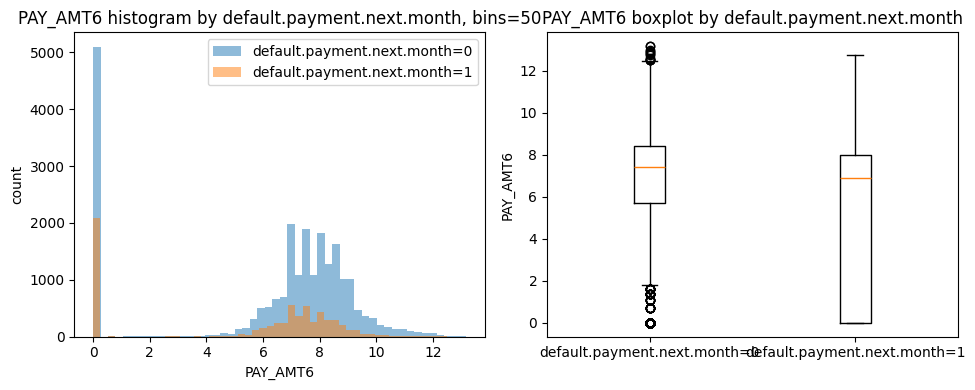

In [39]:
for col in PAY_AMT:
    print(f"min values: {df[col].min()}")
    num_vs_target(col)

now the values distribution is quite good. One thing to do not forget is i must do the standardscaler for the BILL_AMT in the pipelines.

In [40]:
def numeric_corr_matrices(num_cols, df=df,target=target)-> None:
    cols = list(num_cols)
    if target not in cols:
        cols = cols + [target]

    pearson = df[cols].corr(method="pearson")   # линейные связи
    spearman = df[cols].corr(method="spearman") # монотонные/нелинейные (по рангам)
    print("======" * 10)
    print("Pearson correlation matrix:")
    print(pearson)
    print("------" * 10)
    print("Spearman correlation matrix:")
    print(spearman)
    print("======" * 10)

In [41]:
cat_cols.append("AGE_BIN")

In [42]:
num_cols=list(set(df.columns)-set(cat_cols))

In [43]:
numeric_corr_matrices(num_cols=num_cols)

Pearson correlation matrix:
                            BILL_AMT6  BILL_AMT2  default.payment.next.month  \
BILL_AMT6                    1.000000   0.724386                   -0.006820   
BILL_AMT2                    0.724386   1.000000                   -0.011887   
default.payment.next.month  -0.006820  -0.011887                    1.000000   
PAY_AMT2                     0.286781   0.304577                   -0.150030   
LIMIT_BAL                    0.253184   0.227652                   -0.153520   
PAY_AMT4                     0.360791   0.330626                   -0.126043   
PAY_AMT1                     0.266994   0.365161                   -0.170300   
AGE                          0.041686   0.043364                    0.013890   
BILL_AMT1                    0.702122   0.838556                   -0.018370   
BILL_AMT5                    0.835520   0.751093                   -0.007084   
BILL_AMT4                    0.787009   0.778919                   -0.010769   
PAY_AMT5    

even if the BILL_AMT or PAY_AMT has quite a lot correlation with each other i still not gonna remove them, that is why now i am gonna focus on other features: AGE, LIMIT_BALL, target

>AGE, LIMIT_BAL_LOG: correlation with other features is not big, which means they can give additional info which is good

I will remove the ```LIMIT_BAL```

In [44]:
df.drop(columns=["LIMIT_BAL"], inplace=True)
num_cols.remove("LIMIT_BAL")

In [45]:
test_df.drop(columns=["LIMIT_BAL"], inplace=True)


In [46]:
def cramers_v_from_crosstab(tab):
    chi2, p, dof, expected = stats.chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, k = tab.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1) + 1e-12))
    return float(v), float(p)

def cat_to_target(df, cat_col, target=target):
    tab = pd.crosstab(df[cat_col], df[target])
    rate = df.groupby(cat_col)[target].mean().sort_values(ascending=False)

    v, p = cramers_v_from_crosstab(tab)

    print(f"\n=== {cat_col} -> {target} ===")
    print("Default rate by category:\n", rate)
    print("\nCrosstab:\n", tab)
    print(f"\nCramér’s V: {v:.3f} | chi-square p-value: {p:.6f}")
    print("======" * 10)
    
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2, p, dof, expected = stats.chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return float(np.sqrt((chi2 / n) / (min(r - 1, k - 1) + 1e-12)))

def cat_to_cat_matrix(df, cat_cols):
    M = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

    for c1 in cat_cols:
        for c2 in cat_cols:
            if c1 == c2:
                M.loc[c1, c2] = 1.0
            else:
                M.loc[c1, c2] = cramers_v(df[c1], df[c2])
    return M

here in the cat_to_target function we mostly look at the cramers_v. its value varies from 0 to 1.

0.00–0.10 weak

0.10–0.30 small to moderate

0.30–0.50 moderate to strong

more than 0.50 strong

the p value and cramers_v can be decribed in short as:

p-value answers:“Is there evidence of any association at all?” 
H0->the feat and target are independent
H1->dependent

Cramér’s V answers: “How strong is the association?”

In [47]:
for col in cat_cols:
    cat_to_target(df, col)


=== SEX -> default.payment.next.month ===
Default rate by category:
 SEX
male      0.241672
female    0.207763
Name: default.payment.next.month, dtype: float64

Crosstab:
 default.payment.next.month      0     1
SEX                                    
female                      14349  3763
male                         9015  2873

Cramér’s V: 0.040 | chi-square p-value: 0.000000

=== EDUCATION -> default.payment.next.month ===
Default rate by category:
 EDUCATION
high school        0.251576
university         0.237349
graduate school    0.192348
others             0.070513
Name: default.payment.next.month, dtype: float64

Crosstab:
 default.payment.next.month      0     1
EDUCATION                              
graduate school              8549  2036
high school                  3680  1237
others                        435    33
university                  10700  3330

Cramér’s V: 0.073 | chi-square p-value: 0.000000

=== MARRIAGE -> default.payment.next.month ===
Default rate by cate

C:\Users\User\AppData\Local\Temp\ipykernel_6520\3091393779.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(cat_col)[target].mean().sort_values(ascending=False)


From the graph it can be seen that for the PAY_N the p value and V value are being quite good, which means there is quite qood connection
But the other feat showing the p value :0 but the V value i quite weak, which means that statistically there is a connection but it is quite weak or useless. I am not gonna remove them but will check them with the baseline

Mostlikely when making the final features i am gonna add the PAY_N, PAY_AMT, and BILL_AMT at the beginning because that is the must for our current task

In [48]:
#here it can be seen that the Cramer's V is weak for AGE_BIN.
#That is why i need to test other bins to maximize the V value
bins   = [21, 25, 30, 35, 45, np.inf]
labels = ["21-25", "25-30", "30-35", "35-45", "45+"]
df['AGE_BIN']=pd.cut(df['AGE'], bins=bins, labels=labels, right=False)
cat_to_target(df, "AGE_BIN")
#that is the maximum i was able to get




=== AGE_BIN -> default.payment.next.month ===
Default rate by category:
 AGE_BIN
21-25    0.271881
45+      0.244798
35-45    0.218563
25-30    0.211597
30-35    0.193156
Name: default.payment.next.month, dtype: float64

Crosstab:
 default.payment.next.month     0     1
AGE_BIN                               
21-25                       1955   730
25-30                       5466  1467
30-35                       4904  1174
35-45                       7047  1971
45+                         3992  1294

Cramér’s V: 0.054 | chi-square p-value: 0.000000


C:\Users\User\AppData\Local\Temp\ipykernel_6520\3091393779.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(cat_col)[target].mean().sort_values(ascending=False)


In [49]:
#the same for test dataset
test_df['AGE_BIN']=pd.cut(test_df['AGE'], bins=bins, labels=labels, right=False)


In [50]:
Vmat=cat_to_cat_matrix(df, cat_cols=cat_cols)
print(Vmat)

                SEX  EDUCATION  MARRIAGE     PAY_0     PAY_2     PAY_3  \
SEX        1.000000   0.028234  0.031022  0.066900  0.075460  0.072468   
EDUCATION  0.028234   1.000000  0.134693  0.115481  0.124298  0.120560   
MARRIAGE   0.031022   0.134693  1.000000  0.041491  0.042895  0.039763   
PAY_0      0.066900   0.115481  0.041491  1.000000  0.625402  0.498712   
PAY_2      0.075460   0.124298  0.042895  0.625402  1.000000  0.626747   
PAY_3      0.072468   0.120560  0.039763  0.498712  0.626747  1.000000   
PAY_4      0.065867   0.110677  0.043787  0.454292  0.508129  0.681681   
PAY_5      0.057697   0.100592  0.042079  0.468702  0.499627  0.562078   
PAY_6      0.048350   0.098034  0.038088  0.438607  0.464350  0.515371   
AGE_BIN    0.094219   0.146933  0.352071  0.062638  0.066604  0.062885   

              PAY_4     PAY_5     PAY_6   AGE_BIN  
SEX        0.065867  0.057697  0.048350  0.094219  
EDUCATION  0.110677  0.100592  0.098034  0.146933  
MARRIAGE   0.043787  0.042079

I do not see huge correlations

There are 2 most popular approaches for selecting the useful features:

1) griddy selection. choose one by one while it shows improvements

2) regulization l1(lasso)
then the approach for validating the selected features: Permutation importance

NOTE: The test_df will not be used to evaluate instead i will use splitting for folds. the test_df will be used to make the last verdict about the features and see the baseline performance

In [51]:
def run_logreg_experiments(
    df,
    target=target,
    experiments=None,
    cv_splits=5,
    scoring="roc_auc",
    random_state=42
):
    if experiments is None:
        raise ValueError("Pass experiments=dict(name -> list_of_features)")

    y = df[target]

    def make_pipe(features):
        X = df[features]

        num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        ord_cols=PAY_N
        cat_cols = [c for c in features if c not in num_cols and c not in ord_cols]
        ordinal_categories = [[-2, -1, 0, 1, 2, 3]] * len(ord_cols)
        pre = ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("impute", SimpleImputer(strategy="median")),
                    ("ss", StandardScaler())
                ]), num_cols),
                ("ord", Pipeline(steps=[
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("ordenc", OrdinalEncoder(
                        categories=ordinal_categories,
                        handle_unknown="use_encoded_value",
                        unknown_value=-1
                ))
                    ]), ord_cols),
                ("cat", Pipeline(steps=[
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore"))
                ]), cat_cols),
            ],
            remainder="drop"
        )

        model = LogisticRegression(max_iter=2000, solver="lbfgs")

        pipe = Pipeline(steps=[("pre", pre), ("model", model)])
        return pipe, X

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    results = []
    for name, features in experiments.items():
        pipe, X = make_pipe(features)
        scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring)
        results.append({
            "experiment": name,
            "n_features": len(features),
            "features": features,
            "cv_scores": scores.tolist(),        
            "mean": float(scores.mean()),
            "std": float(scores.std()),
            "min": float(scores.min()),
            "max": float(scores.max()),
        })

    out = pd.DataFrame(results)
    # compact print
    print(out[["experiment", "n_features", "mean", "std", "cv_scores"]].to_string(index=True))
    return out



In [52]:
BASE_EXPERIMENT=['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4','PAY_5', 'PAY_6', 'PAY_AMT6', 'BILL_AMT5', 'PAY_AMT2', 'BILL_AMT4','BILL_AMT6','BILL_AMT1','PAY_AMT4','BILL_AMT3', 'PAY_AMT1', 'PAY_AMT3','BILL_AMT2', 'PAY_AMT5',]
CHECK_EXPERIMENT=list(set(df.columns)-set(BASE_EXPERIMENT))
CHECK_EXPERIMENT.remove(target)

In [53]:
CHECK_EXPERIMENT

['EDUCATION', 'AGE_BIN', 'SEX', 'AGE', 'MARRIAGE', 'LIMIT_BAL_LOG']

In [54]:
experiments={
    "BASE": BASE_EXPERIMENT,
    "BASE + AGE_BIN": BASE_EXPERIMENT + ["AGE_BIN"],
    "BASE + AGE": BASE_EXPERIMENT + ["AGE"], # AGE_BIN is better
    "BASE + AGE_BIN + EDUCATION": BASE_EXPERIMENT + ["AGE_BIN"] + ['EDUCATION'],
    "BASE + AGE_BIN + EDUCATION + LIMIT_BAL_LOG": BASE_EXPERIMENT + ["AGE_BIN", 'EDUCATION', 'LIMIT_BAL_LOG'],
    "BASE + AGE_BIN + EDUCATION + LIMIT_BAL_LOG + SEX": BASE_EXPERIMENT + ["AGE_BIN", 'EDUCATION', 'LIMIT_BAL_LOG', "SEX"],
    "BASE + AGE_BIN + EDUCATION + LIMIT_BAL_LOG + MARRIAGE": BASE_EXPERIMENT + ["AGE_BIN", 'EDUCATION', 'LIMIT_BAL_LOG', 'MARRIAGE'],
    "BASE + AGE_BIN + EDUCATION + LIMIT_BAL_LOG + MARRIAGE + SEX":BASE_EXPERIMENT + ["AGE_BIN", 'EDUCATION', 'LIMIT_BAL_LOG', 'MARRIAGE', "SEX"],
    "BASE + EDUCATION + LIMIT_BAL_LOG + MARRIAGE + SEX":BASE_EXPERIMENT + ['EDUCATION', 'LIMIT_BAL_LOG', 'MARRIAGE', "SEX"],

    "BASE + ALL_CHECK_EXPERIMENT": BASE_EXPERIMENT+CHECK_EXPERIMENT



}
results = run_logreg_experiments(df=df, target=target, experiments=experiments, scoring="roc_auc", cv_splits=5)

                                                    experiment  n_features      mean       std                                                                                             cv_scores
0                                                         BASE          18  0.739124  0.005003  [0.7451999511315811, 0.7309946136723802, 0.7370054301910106, 0.7390914408172395, 0.7433282089497122]
1                                               BASE + AGE_BIN          19  0.740520  0.004894   [0.745340012661949, 0.7315817703103222, 0.7397235090519042, 0.7415788337208201, 0.7443749636151561]
2                                                   BASE + AGE          19  0.740103  0.004493  [0.7442873753146146, 0.7319865390994555, 0.7389755737355692, 0.7413084771969228, 0.7439551974167044]
3                                   BASE + AGE_BIN + EDUCATION          20  0.741858  0.005091   [0.7469940764771413, 0.7325370085264302, 0.741465949994767, 0.7424572303719793, 0.7458343082993245]
4              

In [55]:
#it is not the best score but still I consider it as more stable 
# with fewer features and a little bit lower roc-auc score
final_feature_grid=BASE_EXPERIMENT + ["AGE_BIN", 'EDUCATION', 'LIMIT_BAL_LOG', "SEX", "MARRIAGE"]

In [56]:
results.iloc[7].cv_scores
# to see if the result in consistent with other folds. check for lucky split

[0.7522650802267288,
 0.7377987608914655,
 0.7444334212590051,
 0.744770137287575,
 0.7516887808573713]

In [57]:
df.drop(columns=["AGE"], inplace=True)
test_df.drop(columns=["AGE"], inplace=True)

In [58]:
def l1_logreg_feature_selection(df, features, target=target, scoring="roc_auc", cv_splits=5, random_state=42):
    X = df[features]
    y = df[target]

    ord_cols = [c for c in PAY_N if c in X.columns]
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ord_cols]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in ord_cols)]
    ord_order = [-2, -1, 0, 1, 2, 3]
    ordinal_categories = [ord_order] * len(ord_cols)

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                    ("impute", SimpleImputer(strategy="median")),
                    ("ss", StandardScaler())
                ]), num_cols),
            ("ord", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("ordenc", OrdinalEncoder(
                    categories=ordinal_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ))
                ]), ord_cols),
            ("cat", Pipeline(steps=[
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", drop='first'))
                ]), cat_cols),
        ],
        remainder="drop"
    )

    model = LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000)

    pipe = Pipeline(steps=[("pre", pre), ("model", model)])

    # C:(smaller C -> stronger regularization -> fewer features)
    param_grid = {"model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    gs = GridSearchCV(pipe, param_grid=param_grid, scoring=scoring, cv=cv, n_jobs=-1, refit=True)
    gs.fit(X, y)

    best_pipe = gs.best_estimator_
    best_C = gs.best_params_["model__C"]
    best_score = gs.best_score_

    feature_names = best_pipe.named_steps["pre"].get_feature_names_out()
    coef = best_pipe.named_steps["model"].coef_.ravel()

    selected_mask = np.abs(coef) > 1e-8

    selected = (pd.DataFrame({
        "feature": feature_names[selected_mask],
        "coef": coef[selected_mask]
    })
    .sort_values("coef", key=np.abs, ascending=False)
    .reset_index(drop=True))

    print(f"Best C = {best_C} | CV {scoring} = {best_score:.4f}")
    print(f"Selected features (non-zero): {selected.shape[0]} / {len(feature_names)}")

    return gs, selected

In [59]:
all_features = df.columns.drop(target).tolist()

gs, selected = l1_logreg_feature_selection(df, all_features, target=target, scoring="roc_auc")
display(selected.head(30))

c:\Users\User\all_project\projects_in_github\taiwan2005_credict_card_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\all_project\projects_in_github\taiwan2005_credict_card_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best C = 3 | CV roc_auc = 0.7462
Selected features (non-zero): 29 / 29


,feature,coef
0,cat__EDUCATION_others,-1.107011
1,ord__PAY_0,0.487617
2,cat__MARRIAGE_others,-0.187737
3,num__PAY_AMT1,-0.185854
4,cat__MARRIAGE_single,-0.181620
5,num__PAY_AMT3,-0.152456
6,num__PAY_AMT2,-0.150221
7,num__LIMIT_BAL_LOG,-0.129191
8,num__PAY_AMT4,-0.120190
9,ord__PAY_6,0.097765


I see no features that can be removed!:(

In [60]:
final_features=final_feature_grid

In [61]:
final_features

['PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'PAY_AMT6',
 'BILL_AMT5',
 'PAY_AMT2',
 'BILL_AMT4',
 'BILL_AMT6',
 'BILL_AMT1',
 'PAY_AMT4',
 'BILL_AMT3',
 'PAY_AMT1',
 'PAY_AMT3',
 'BILL_AMT2',
 'PAY_AMT5',
 'AGE_BIN',
 'EDUCATION',
 'LIMIT_BAL_LOG',
 'SEX',
 'MARRIAGE']

In [62]:
X = df[final_features]
y = df[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3) Build the same preprocessing pipeline
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
ord_cols=PAY_N
cat_cols = [c for c in final_features if c not in num_cols and c not in ord_cols]
ordinal_categories = [[-2, -1, 0, 1, 2, 3]] * len(ord_cols)
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
                    ("impute", SimpleImputer(strategy="median")),
                    ("ss", StandardScaler())
                ]), num_cols),
        ("ord", Pipeline(steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ordenc", OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), ord_cols),
        ("cat", Pipeline(steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))  # optional drop for cleaner features
        ]), cat_cols),
    ],
    remainder="drop"
)

model = LogisticRegression(max_iter=5000, solver="lbfgs")

pipe = Pipeline(steps=[("pre", pre), ("model", model)])

# 4) Fit
pipe.fit(X_train, y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [63]:
r = permutation_importance(
    pipe,
    X_valid,
    y_valid,
    n_repeats=30,              # more repeats = more stable
    random_state=42,
    scoring="roc_auc"          
)

imp = pd.DataFrame({
    "feature": final_features,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std,
}).sort_values("importance_mean", ascending=False)

print(imp)

          feature  importance_mean  importance_std
0           PAY_0         0.065193        0.005673
14       PAY_AMT1         0.011426        0.001838
8        PAY_AMT2         0.007753        0.001267
15       PAY_AMT3         0.007596        0.001942
12       PAY_AMT4         0.005754        0.000820
20  LIMIT_BAL_LOG         0.004718        0.001459
22       MARRIAGE         0.002913        0.000725
17       PAY_AMT5         0.002192        0.000602
13      BILL_AMT3         0.001958        0.001041
6        PAY_AMT6         0.001922        0.000571
19      EDUCATION         0.001602        0.001019
18        AGE_BIN         0.001559        0.000613
21            SEX         0.000768        0.000443
11      BILL_AMT1         0.000465        0.000331
9       BILL_AMT4         0.000276        0.001309
10      BILL_AMT6         0.000190        0.000121
7       BILL_AMT5        -0.000262        0.000134
1           PAY_2        -0.000334        0.000589
4           PAY_5        -0.000

In [64]:
meta={
    "target": target,
    "final_features": final_features,
    'PAY_N': PAY_N,
    'PAY_AMT': PAY_AMT,
    'BILL_AMT': BILL_AMT,
    "metric": "roc_auc",
    "random_state": 42
}

In [65]:
with open(FEATURES_PATH, "w", encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

In [69]:
os.makedirs(TRAIN_PREPRO_PATH.parent, exist_ok=True)
os.makedirs(TEST_PREPRO_PATH.parent, exist_ok=True)
test_df.to_csv(TEST_PREPRO_PATH, index=False)
df.to_csv(TRAIN_PREPRO_PATH, index=False)